# Course Study Assistant — Notebook 2: RAG · LoRA · Evaluation · Demo

## **Tamar Telele** | Applied Language Models | Dr. Barak Or
### Google & Reichman University Tech School

---

Notebook 1 produced the dataset. This notebook turns it into two competing systems,
measures them against each other, and ships the winner behind a live interface.

### The question
> **When does retrieval beat parameter-efficient fine-tuning on course-specific QA — and why?**

Both systems sit on the same frozen checkpoint, `google/flan-t5-base`. Holding the base model
constant is what makes this a controlled experiment: every difference measured in Part C is
attributable to the method, not to model capacity.

### Map of the notebook

| Part | Cells | Content |
|---|---|---|
| **A — RAG Pipeline** | 3–13 | 3 chunking strategies · embeddings · FAISS · Dense / BM25 / Hybrid · Hit@k & MRR · guardrails |
| **B — LoRA Fine-Tuning** | 14–21 | 3 tokenizations · sequential search over `r`, `alpha`, `dropout` · training curves |
| **C — Evaluation** | 22–26 | ROUGE-L · BLEU · hallucination rate · error analysis · radar chart |
| **D — Demo** | 27–28 | Gradio interface comparing RAG vs LoRA vs Hybrid, live |

**Input** — the artefacts written by Notebook 1 to `MyDrive/course_study_assistant/data/`.

## Cell 1 — Setup, Installation & Global Configuration

A single frozen `Config` holds every RAG and LoRA hyperparameter.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 1 — Setup, Installation & Global Configuration
# ═══════════════════════════════════════════════════════════════════════════════

!pip install -q --upgrade torchao
!pip install -q transformers peft datasets accelerate sentence-transformers \
                faiss-cpu rank-bm25 langchain-text-splitters evaluate rouge_score \
                sacrebleu nltk gradio

# --- Standard library ---
from google.colab import userdata
import gc
import json
import os
import random
import re
import time
import warnings
from bisect import bisect_right
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

# --- Scientific stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# --- NLP / retrieval stack ---
import faiss
import evaluate
import nltk
from nltk.tokenize import word_tokenize
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.manifold import TSNE

# --- HuggingFace + PEFT ---
from transformers import (AutoTokenizer, AutoModelForSeq2SeqLM,
                          DataCollatorForSeq2Seq, Seq2SeqTrainer,
                          Seq2SeqTrainingArguments, EarlyStoppingCallback)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset

import gradio as gr
from tqdm.auto import tqdm
from google.colab import drive

warnings.filterwarnings("ignore", category=FutureWarning)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)


# ───────────────────────────────────────────────────────────────────────────────
#  Global configuration — single source of truth
# ───────────────────────────────────────────────────────────────────────────────
@dataclass(frozen=True)
class Config:
    """Every experimental knob in this notebook, in one immutable place."""

    # -- Storage --------------------------------------------------------------
    DRIVE_ROOT: Path = Path("/content/drive/MyDrive")
    PROJECT_FOLDER: str = "course_study_assistant"

    # -- Models ---------------------------------------------------------------
    BASE_MODEL: str = "google/flan-t5-base"
    EMBEDDING_MODEL: str = "sentence-transformers/all-MiniLM-L6-v2"

    # -- RAG: chunking strategies (name -> (chunk_tokens, overlap_tokens)) -----
    CHUNK_STRATEGIES: Tuple[Tuple[str, int, int], ...] = (
        ("sentence-level",  50,  10),
        ("paragraph-level", 300, 50),
        ("slide-level",     500, 75),
    )
    SEPARATORS: Tuple[str, ...] = ("\n\n", "\n", ".", " ")

    # -- RAG: retrieval -------------------------------------------------------
    TOP_K: int = 3
    HYBRID_ALPHAS: Tuple[float, ...] = (0.3, 0.5, 0.7)
    ALPHA_SWEEP: Tuple[float, ...] = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)

    # -- RAG: generation parameters ------------------------
    GEN_TEMPERATURE: float = 0.1
    GEN_MAX_NEW_TOKENS: int = 100
    GEN_MIN_NEW_TOKENS: int = 15     # floor — eliminates one-token answers;half the p10 reference length (~28 tok)
    GEN_NUM_BEAMS: int = 4   # deterministic beam search (do_sample=False)
    GEN_NO_REPEAT_NGRAM: int = 3     # hard-blocks repeated trigrams — cleaner than per-token repetition_penalty
    GEN_REPETITION_PENALTY: float = 1.2  # kept alongside no_repeat_ngram_size
    GEN_DO_SAMPLE: bool = False
    GEN_MAX_INPUT_LENGTH: int = 512

    # -- LoRA: search space  ---------------------------
    TOKENIZATIONS: Tuple[str, ...] = ("word", "subword", "char")
    LORA_R_VALUES: Tuple[int, ...] = (4, 8, 16)
    LORA_ALPHA_VALUES: Tuple[int, ...] = (8, 16, 32)
    LORA_DROPOUT_VALUES: Tuple[float, ...] = (0.05, 0.1)
    LORA_TARGET_MODULES: Tuple[str, ...] = ("q", "v")
    DEFAULT_R: int = 8
    DEFAULT_ALPHA: int = 16
    DEFAULT_DROPOUT: float = 0.1

    # -- LoRA: training -----------------------------------
    EPOCHS: int = 3
    BATCH_SIZE: int = 8
    LEARNING_RATE: float = 3e-4
    WARMUP_STEPS: int = 50
    EARLY_STOPPING_PATIENCE: int = 3
    MAX_SOURCE_LENGTH: int = 384
    MAX_TARGET_LENGTH: int = 96

    # -- Experiment budget ----------------------------------------------------
    SEARCH_VAL_SUBSET: int = 100   # validation subset used during the search (speed)
    FILL_HEATMAP_GRID: bool = True # +4 runs to complete the 3x3 r×alpha heatmap
    ERROR_ANALYSIS_N: int = 30

    # -- Reproducibility ------------------------------------------------------
    SEED: int = 42

    # -- Derived paths --------------------------------------------------------
    @property
    def project_dir(self) -> Path:  return self.DRIVE_ROOT / self.PROJECT_FOLDER
    @property
    def data_dir(self) -> Path:     return self.project_dir / "data"
    @property
    def figures_dir(self) -> Path:  return self.project_dir / "figures"
    @property
    def models_dir(self) -> Path:   return self.project_dir / "models"
    @property
    def results_dir(self) -> Path:  return self.project_dir / "results"
    @property
    def reports_dir(self) -> Path:  return self.project_dir / "reports"

    def output_dirs(self) -> List[Path]:
        return [self.project_dir, self.data_dir, self.figures_dir,
                self.models_dir, self.results_dir, self.reports_dir]


CFG = Config()


# ───────────────────────────────────────────────────────────────────────────────
#  Reproducibility
# ───────────────────────────────────────────────────────────────────────────────
def set_global_seed(seed: int) -> None:
    """Fix every source of randomness, including CUDA."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_global_seed(CFG.SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ───────────────────────────────────────────────────────────────────────────────
#  Console helpers — every cell reports through these, so the log stays readable
# ───────────────────────────────────────────────────────────────────────────────
RULE = "=" * 79


def section(title: str, *lines: str) -> None:
    """Print a section header, plus any fixed settings that belong inside it."""
    print(f"\n{RULE}\n  {title}")
    for line in lines:
        print(f"  {line}")
    print(RULE)


def rule() -> None:
    """Close a section."""
    print(RULE)


# ───────────────────────────────────────────────────────────────────────────────
#  Consistent, report-ready plotting style
# ───────────────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.titleweight": "bold",
    "axes.titlesize": 13, "font.size": 11,
})
PALETTE = ["#2E86AB", "#F6511D", "#7FB800", "#8E44AD", "#FFB400", "#00A6ED"]
METHOD_COLORS = {"dense": PALETTE[0], "bm25": PALETTE[1], "hybrid": PALETTE[2],
                 "RAG": PALETTE[0], "LoRA": PALETTE[1], "Hybrid": PALETTE[2]}

rouge_metric = evaluate.load("rouge")
bleu_metric  = evaluate.load("sacrebleu")

def save_figure(fig, name: str) -> None:
    """Persist a figure to Drive so the report can use it directly."""
    path = CFG.figures_dir / f"{name}.png"
    fig.savefig(path)
    print(f"   figure saved: {path.name}")


# ───────────────────────────────────────────────────────────────────────────────
#  Mount Drive and prepare folders
# ───────────────────────────────────────────────────────────────────────────────
drive.mount("/content/drive", force_remount=False)
for directory in CFG.output_dirs():
    directory.mkdir(parents=True, exist_ok=True)

section("COURSE STUDY ASSISTANT  |  NOTEBOOK 2 — RAG + LoRA + EVALUATION + DEMO",
        "Tamar Telele  |  Applied Language Models  |  Dr. Barak Or")
print(f"  Run started    : {datetime.now():%Y-%m-%d %H:%M:%S}")
print(f"  Device         : {DEVICE.upper()}"
      f"{' — ' + torch.cuda.get_device_name(0) if DEVICE == 'cuda' else ''}")
print(f"  Base model     : {CFG.BASE_MODEL}")
print(f"  Embedding model: {CFG.EMBEDDING_MODEL}")
print(f"  Seed           : {CFG.SEED}")
if DEVICE == "cpu":
    print("  WARNING: no GPU detected. Part A will run, Part B (LoRA) will be very slow.")
    print("           Runtime -> Change runtime type -> T4 GPU.")
rule()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  COURSE STUDY ASSISTANT  |  NOTEBOOK 2 — RAG + LoRA + EVALUATION + DEMO
  Tamar Telele  |  Applied Language Models  |  Dr. Barak Or
  Run started    : 2026-09-14 19:44:53
  Device         : CUDA — Tesla T4
  Base model     : google/flan-t5-base
  Embedding model: sentence-transformers/all-MiniLM-L6-v2
  Seed           : 42


## Cell 2 — Loading the Dataset Produced by Notebook 1

The artefacts are loaded and the contract is verified — split sizes, no question shared
between train and test, and a non-empty corpus. A missing or malformed artefact fails here,
loudly, which is far better than an obscure error forty minutes into a training run.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 2 — Load the dataset & corpus produced by Notebook 1
# ═══════════════════════════════════════════════════════════════════════════════

def load_json(path: Path):
    """Load a JSON artefact with a helpful error if Notebook 1 has not been run."""
    if not path.exists():
        raise FileNotFoundError(
            f"Missing artefact: {path}\nRun Notebook 1 (Data Preparation) first."
        )
    return json.loads(path.read_text(encoding="utf-8"))


train_records = load_json(CFG.data_dir / "qa_train.json")
val_records   = load_json(CFG.data_dir / "qa_val.json")
test_records  = load_json(CFG.data_dir / "qa_test.json")
corpus_records = load_json(CFG.data_dir / "clean_corpus.json")
manifest = load_json(CFG.data_dir / "manifest.json")

train_df = pd.DataFrame(train_records)
val_df   = pd.DataFrame(val_records)
test_df  = pd.DataFrame(test_records)
corpus_df = pd.DataFrame(corpus_records)

# --- Contract verification ------------------------------------------------------
def normalise(text: str) -> str:
    return re.sub(r"\W+", " ", str(text).lower()).strip()


train_keys = {normalise(q) for q in train_df["question"]}
test_keys  = {normalise(q) for q in test_df["question"]}
assert not (train_keys & test_keys), "LEAKAGE: a question appears in both train and test"
assert len(corpus_df) > 0, "The cleaned corpus is empty."

overview = pd.DataFrame({
    "split": ["train", "validation", "test", "corpus pages"],
    "size": [len(train_df), len(val_df), len(test_df), len(corpus_df)],
    "topics": [train_df["topic"].nunique(), val_df["topic"].nunique(),
               test_df["topic"].nunique(), corpus_df["source"].nunique()],
})

section("DATASET LOADED FROM NOTEBOOK 1")
display(overview)
print(f"  Dataset created : {manifest['created_at']}")
print(f"  Generator model : {manifest['generator_model']}")
print(f"  Judge pass rate : {manifest['quality']['judge_acceptance_rate']:.1%}")
print(f"  Mean judge score: {manifest['quality']['mean_judge_score']} / 5")
print("  Leakage check   : PASSED")
rule()


  DATASET LOADED FROM NOTEBOOK 1


,split,size,topics
0,train,792,468
1,validation,170,150
2,test,168,148
3,corpus pages,626,9


  Dataset created : 2026-08-30T14:08:39
  Generator model : gemini-3.5-flash-lite
  Judge pass rate : 89.1%
  Mean judge score: 4.99 / 5
  Leakage check   : PASSED


---
# PART A — RAG Pipeline
---

## Cell 3 — PDF → Chunks: comparing 3 chunking strategies

The choice of chunking strategy is a key factor in building an effective RAG system:
too small and the chunk loses its context; too large and the embedding is diluted and precision drops.
So three strategies are measured rather than assumed, and selected on
`Hit@3` / `MRR` over the validation set.

| Strategy | Size | Overlap | Expected to win on |
|---|---|---|---|
| sentence-level | 50 tokens | 10 (20%) | very specific factual questions |
| paragraph-level | 300 tokens | 50 (17%) | balance of context and precision |
| slide-level | 500 tokens | 75 (15%) | broad, conceptual questions |

**Two implementation details carry the rest of the notebook:**
- The splitter is built **from the flan-t5 tokenizer**, so 50 / 300 / 500 are true token
  counts rather than a character approximation.
- `add_start_index=True` maps every chunk back to its **source PDF and page range**. That
  provenance is what makes retrieval evaluation (Cell 9) and error analysis (Cell 23) possible
  without a manual label.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 3 — Chunking: three strategies, with full page-level provenance
# ═══════════════════════════════════════════════════════════════════════════════

# The flan-t5 tokenizer is used only as the length function here, so that chunk sizes
# are expressed in the same token units (50 / 300 / 500 tokens).
length_tokenizer = AutoTokenizer.from_pretrained(CFG.BASE_MODEL)


def build_document_index(corpus: pd.DataFrame) -> Dict[str, Dict]:
    """Concatenate each PDF's pages and remember where every page starts.

    Returns {source: {"text": full_text, "offsets": [...], "pages": [...]}} so that a
    character position inside the concatenated text can be resolved back to a page number.
    """
    documents: Dict[str, Dict] = {}
    for source, group in corpus.groupby("source", sort=False):
        group = group.sort_values("page")
        offsets, pages, cursor, parts = [], [], 0, []
        for _, row in group.iterrows():
            text = str(row["text"]).strip()
            if not text:
                continue
            offsets.append(cursor)
            pages.append(int(row["page"]))
            parts.append(text)
            cursor += len(text) + 1                    # +1 for the joining newline
        documents[source] = {"text": "\n".join(parts), "offsets": offsets, "pages": pages}
    return documents


def resolve_page(document: Dict, position: int) -> int:
    """Map a character position inside a concatenated document back to its page number."""
    index = bisect_right(document["offsets"], position) - 1
    index = max(0, min(index, len(document["pages"]) - 1))
    return document["pages"][index]


def chunk_corpus(documents: Dict[str, Dict], chunk_tokens: int,
                 overlap_tokens: int, strategy_name: str) -> List[Dict]:
    """Split every document with RecursiveCharacterTextSplitter, keeping provenance."""
    splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer=length_tokenizer,
        chunk_size=chunk_tokens,
        chunk_overlap=overlap_tokens,
        separators=list(CFG.SEPARATORS),
        add_start_index=True,
    )

    chunks: List[Dict] = []
    for source, document in documents.items():
        for piece in splitter.create_documents([document["text"]]):
            text = piece.page_content.strip()
            if len(text) < 30:                          # skip fragments with no content
                continue
            start = piece.metadata.get("start_index", 0)
            chunks.append({
                "chunk_id": f"{strategy_name}::{source}::{len(chunks):05d}",
                "strategy": strategy_name,
                "source": source,
                "page_start": resolve_page(document, start),
                "page_end": resolve_page(document, start + len(text)),
                "text": text,
                "n_tokens": len(length_tokenizer.encode(text, add_special_tokens=False)),
            })
    return chunks


# --- Build all three chunk sets --------------------------------------------------
documents = build_document_index(corpus_df)
chunk_sets: Dict[str, List[Dict]] = {}

for strategy_name, size, overlap in CFG.CHUNK_STRATEGIES:
    chunk_sets[strategy_name] = chunk_corpus(documents, size, overlap, strategy_name)
    print(f"  {strategy_name:<16} -> {len(chunk_sets[strategy_name]):>5,} chunks")

# --- Comparison table -------------------------------------------------------------
chunk_stats = pd.DataFrame([
    {
        "strategy": name,
        "chunks": len(chunks),
        "avg_tokens": round(float(np.mean([c["n_tokens"] for c in chunks])), 1),
        "median_tokens": int(np.median([c["n_tokens"] for c in chunks])),
        "avg_chars": int(np.mean([len(c["text"]) for c in chunks])),
    }
    for name, chunks in chunk_sets.items()
])

section("CHUNKING STRATEGY COMPARISON")
display(chunk_stats)
print(f"  Documents indexed: {len(documents)}   |   Separators: {list(CFG.SEPARATORS)}")
rule()

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

  sentence-level   -> 1,407 chunks
  paragraph-level  ->   208 chunks
  slide-level      ->   125 chunks

  CHUNKING STRATEGY COMPARISON


,strategy,chunks,avg_tokens,median_tokens,avg_chars
0,sentence-level,1407,39.0,42,185
1,paragraph-level,208,282.9,290,1348
2,slide-level,125,472.0,491,2251


  Documents indexed: 9   |   Separators: ['\n\n', '\n', '.', ' ']


## Cell 4 — Embeddings with `all-MiniLM-L6-v2`

384-dimensional vectors from a 22M-parameter encoder.

Every vector is **L2-normalised**, which turns the inner product into exact cosine similarity.
That bounded [-1, 1] scale is a prerequisite for the abstention threshold calibrated in Cell 11,
which needs a score that is comparable across questions.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...


  Strategy: paragraph-level


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


  Strategy: slide-level


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


  EMBEDDING SUMMARY
  sentence-level   matrix shape = (1407, 384)   dtype = float32
  paragraph-level  matrix shape = (208, 384)   dtype = float32
  slide-level      matrix shape = (125, 384)   dtype = float32
  Embedding dimension : 384
  Normalised          : True
   figure saved: rag_tsne_chunk_embeddings_all_strategies.png


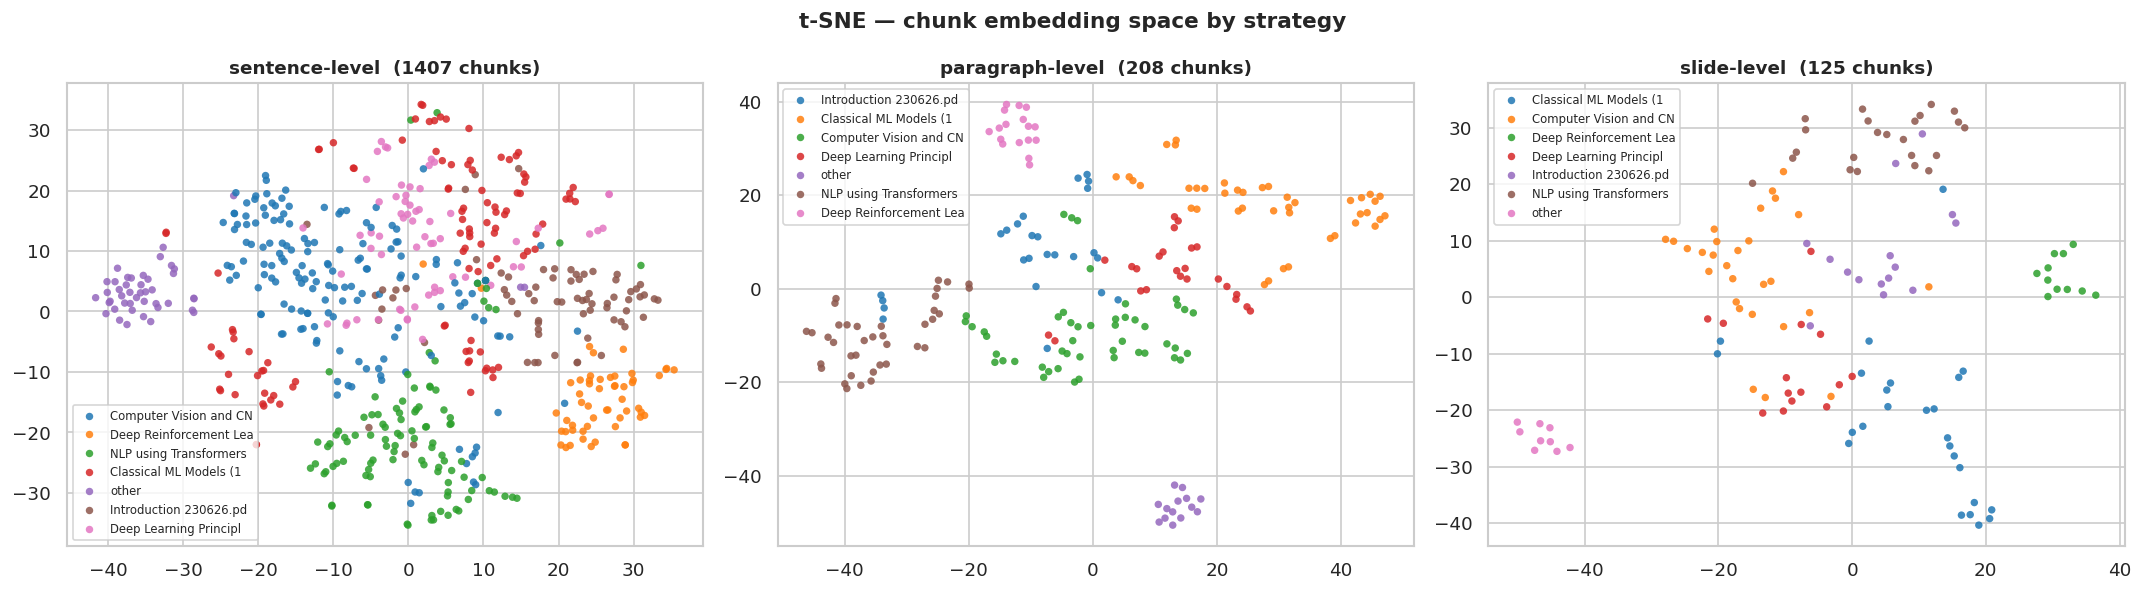

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 4 — Embedding all chunk sets with all-MiniLM-L6-v2
# ═══════════════════════════════════════════════════════════════════════════════

embedder = SentenceTransformer(CFG.EMBEDDING_MODEL, device=DEVICE)
EMBEDDING_DIM = embedder.get_sentence_embedding_dimension()


def embed_texts(texts: List[str], batch_size: int = 64) -> np.ndarray:
    """Encode texts into L2-normalised float32 vectors (inner product = cosine)."""
    vectors = embedder.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    return vectors.astype("float32")


chunk_embeddings: Dict[str, np.ndarray] = {}
for strategy_name, chunks in chunk_sets.items():
    print(f"\n  Strategy: {strategy_name}")
    chunk_embeddings[strategy_name] = embed_texts([c["text"] for c in chunks])

section("EMBEDDING SUMMARY")
for strategy_name, matrix in chunk_embeddings.items():
    print(f"  {strategy_name:<16} matrix shape = {matrix.shape}   dtype = {matrix.dtype}")

first_matrix = next(iter(chunk_embeddings.values()))
is_normalised = np.allclose(np.linalg.norm(first_matrix, axis=1), 1.0, atol=1e-3)
print(f"  Embedding dimension : {EMBEDDING_DIM}")
print(f"  Normalised          : {is_normalised}")
rule()

# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 4b — t-SNE of chunk embeddings (all 3 strategies)
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (strategy_name, _, _) in zip(axes, CFG.CHUNK_STRATEGIES):
    chunks  = chunk_sets[strategy_name]
    vectors = chunk_embeddings[strategy_name]

    idx = np.random.RandomState(CFG.SEED).choice(
        len(chunks), size=min(600, len(chunks)), replace=False)

    proj = TSNE(n_components=2, perplexity=min(30, max(5, len(idx) // 20)),
                init="pca", learning_rate="auto",
                random_state=CFG.SEED).fit_transform(vectors[idx])

    df = pd.DataFrame({"x": proj[:, 0], "y": proj[:, 1],
                       "doc": [chunks[i]["source"][:22] for i in idx]})
    top = df["doc"].value_counts().head(6).index
    df["doc"] = df["doc"].where(df["doc"].isin(top), "other")

    sns.scatterplot(data=df, x="x", y="y", hue="doc",
                    ax=ax, palette="tab10", s=20, alpha=0.85, edgecolor="none")
    ax.set_title(f"{strategy_name}  ({len(chunks)} chunks)", fontsize=11)
    ax.set(xlabel="", ylabel="")
    ax.legend(fontsize=7, frameon=True)

fig.suptitle("t-SNE — chunk embedding space by strategy", fontsize=13, fontweight="bold")
plt.tight_layout()
save_figure(fig, "rag_tsne_chunk_embeddings_all_strategies")
plt.show()

## Embedding Quality — t-SNE Analysis

Projecting the chunk embeddings into 2D reveals that the embedding space separates course topics by source document across all three granularities. The separation is sharpest at the paragraph level (300 tokens), where cluster boundaries are visually distinct — consistent with the retrieval results in Cell 9. Sentence-level chunks (50 tokens) produce a more diffuse layout, as short fragments carry insufficient context for the encoder to anchor them to a single topic. Slide-level chunks (500 tokens) show clear clusters but at low density, limiting the statistical reliability of the projection.


## Cell 5 — FAISS Index

One FAISS index per chunking strategy, built over the L2-normalised embeddings.

`IndexFlatIP` (inner product) is used — since every vector is normalised, inner product equals cosine similarity directly, returning a bounded [-1, 1] score that the guardrail threshold in Cell 11 relies on.

`Flat` means exact, exhaustive search: at a few thousand chunks this costs milliseconds per query and removes any approximation error from the experiment.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 5 — Building the FAISS indexes (one per chunking strategy)
# ═══════════════════════════════════════════════════════════════════════════════

def build_faiss_index(embeddings: np.ndarray) -> faiss.Index:
    """Exact inner-product index over L2-normalised vectors == exact cosine search."""
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    return index


faiss_indexes: Dict[str, faiss.Index] = {
    strategy_name: build_faiss_index(matrix)
    for strategy_name, matrix in chunk_embeddings.items()
}

# --- Sanity check: querying with a chunk's own vector must return that chunk first ---
probe_strategy = CFG.CHUNK_STRATEGIES[1][0]                     # paragraph-level
probe_vector = chunk_embeddings[probe_strategy][0:1]
scores, ids = faiss_indexes[probe_strategy].search(probe_vector, 1)

section("FAISS INDEXES READY")
for strategy_name, index in faiss_indexes.items():
    print(f"  {strategy_name:<16} vectors = {index.ntotal:>6,}   dim = {index.d}")
print(f"  Self-retrieval sanity check: id={int(ids[0][0])} (expected 0), "
      f"cosine={float(scores[0][0]):.4f} (expected ~1.0)")
assert int(ids[0][0]) == 0, "FAISS index is not returning the identity match."
print("  Index integrity: PASSED")
rule()


  FAISS INDEXES READY
  sentence-level   vectors =  1,407   dim = 384
  paragraph-level  vectors =    208   dim = 384
  slide-level      vectors =    125   dim = 384
  Self-retrieval sanity check: id=0 (expected 0), cosine=1.0000 (expected ~1.0)
  Index integrity: PASSED


## Cell 6 — Dense Retrieval

The query is encoded into the same 384-dimensional space as the chunks and retrieved by cosine similarity against the FAISS index.

**Semantic strength, lexical weakness.** Dense retrieval excels at meaning — a question about reducing parameter count retrieves a LoRA chunk with near-zero vocabulary overlap. The trade-off: technical tokens (`ROUGE-L`, `flan-t5-base`, exact hypervalues) are averaged into a single vector and lose their discriminative power. BM25 in Cell 7 is the targeted fix for this.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 6 — Dense Retrieval
# ═══════════════════════════════════════════════════════════════════════════════

def embed_query(query: str) -> np.ndarray:
    """Encode one query with the same normalisation used for the chunks."""
    vector = embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    return vector.astype("float32")


class DenseRetriever:
    """Cosine-similarity retrieval over a FAISS index of normalised embeddings."""

    name = "dense"

    def __init__(self, index: faiss.Index, chunks: List[Dict]):
        self.index = index
        self.chunks = chunks

    def search(self, query: str, k: int = 3) -> List[Tuple[int, float]]:
        """Return the top-k (chunk_index, cosine_similarity) pairs."""
        query_vector = embed_query(query)
        scores, ids = self.index.search(query_vector, min(k, self.index.ntotal))
        return [(int(i), float(s)) for i, s in zip(ids[0], scores[0]) if i != -1]


# --- Smoke test on the default strategy -------------------------------------------
default_strategy = CFG.CHUNK_STRATEGIES[1][0]                    # paragraph-level
dense_retriever = DenseRetriever(faiss_indexes[default_strategy], chunk_sets[default_strategy])

demo_question = val_df["question"].iloc[0]
section("DENSE RETRIEVAL — example")
print(f"  Question: {demo_question}\n")
for rank, (chunk_index, score) in enumerate(dense_retriever.search(demo_question, k=3), start=1):
    chunk = chunk_sets[default_strategy][chunk_index]
    print(f"  #{rank}  cosine={score:.4f}  [{chunk['source']} p.{chunk['page_start']}]")
    print(f"      {chunk['text'][:160]}...")
rule()


  DENSE RETRIEVAL — example
  Question: What are two examples of supervised learning provided in the course material?

  #1  cosine=0.5445  [Introduction 230626.pdf p.1]
      artificial intelligence and deep learning development
machine learning
the process: supervised learning, dogs and cats
prediction
prediction should be
the same ...
  #2  cosine=0.4619  [Introduction 230626.pdf p.55]
      supervised learning
artificial intelligence and deep learning development
machine learning
unsupervised
unsupervised
 definition: a type of machine learning whe...
  #3  cosine=0.4444  [Computer Vision and CNNs - Part 2 120726 (2).pdf p.64]
      models: sam
kirillov, alexander, et al.
medical imaging: assisting in the segmentation of medical scans. autonomous driving: real-time object segmentation for n...


## Cell 7 — BM25 (Sparse Retrieval)

Lexical retrieval over tokenised chunks using Okapi BM25: rare query terms that appear in a document score highly, with term-frequency saturation and document-length normalisation.

**Lexical precision, limited semantic reach.** BM25 excels where Dense fails — exact acronyms, model names, and metric identifiers (`ROUGE-L`, `flan-t5-base`, `alpha=16`). The trade-off: vocabulary mismatch between query and document weakens retrieval even when the meaning is identical.

One implementation note worth stating: BM25 scores are unbounded and corpus-dependent. The hybrid fusion in Cell 8 min-max normalises them per query before combining with cosine similarity — without this step, BM25 would silently dominate the weighted sum.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 7 — BM25 (Sparse) Retrieval
# ═══════════════════════════════════════════════════════════════════════════════

TOKEN_PATTERN = re.compile(r"[a-z0-9]+(?:[-_][a-z0-9]+)*")


def bm25_tokenize(text: str) -> List[str]:
    """Word-level tokenisation that keeps hyphenated technical terms intact.

    'rouge-l' and 'flan-t5-base' must survive as single tokens — splitting them would
    destroy exactly the advantage BM25 is supposed to have over dense retrieval.
    """
    return TOKEN_PATTERN.findall(text.lower())


class BM25Retriever:
    """Sparse lexical retrieval with rank-bm25 (Okapi BM25)."""

    name = "bm25"

    def __init__(self, chunks: List[Dict]):
        self.chunks = chunks
        self.corpus_tokens = [bm25_tokenize(c["text"]) for c in chunks]
        self.bm25 = BM25Okapi(self.corpus_tokens)

    def scores(self, query: str) -> np.ndarray:
        """Raw BM25 score for every chunk in the corpus."""
        return np.asarray(self.bm25.get_scores(bm25_tokenize(query)), dtype="float32")

    def search(self, query: str, k: int = 3) -> List[Tuple[int, float]]:
        scores = self.scores(query)
        top = np.argsort(-scores)[:k]
        return [(int(i), float(scores[i])) for i in top]


bm25_retrievers: Dict[str, BM25Retriever] = {
    strategy_name: BM25Retriever(chunks) for strategy_name, chunks in chunk_sets.items()
}

section("BM25 RETRIEVAL — example (same question as the dense example)")
print(f"  Question: {demo_question}\n")
for rank, (chunk_index, score) in enumerate(
        bm25_retrievers[default_strategy].search(demo_question, k=3), start=1):
    chunk = chunk_sets[default_strategy][chunk_index]
    print(f"  #{rank}  bm25={score:.3f}  [{chunk['source']} p.{chunk['page_start']}]")
    print(f"      {chunk['text'][:160]}...")
rule()


  BM25 RETRIEVAL — example (same question as the dense example)
  Question: What are two examples of supervised learning provided in the course material?

  #1  bm25=16.021  [Introduction 230626.pdf p.49]
      learn from experience e with
respect to some class of tasks t
and performance measure p if its
performance at tasks in t, as
measured by p, improves with
experi...
  #2  bm25=15.045  [Classical ML Models (1).pdf p.23]
      identify all positive instances. example: if there are 60 spam emails and the classifier correctly identifies 40 of them, the recall is
40/60=0. 67 or 67%
predi...
  #3  bm25=14.570  [Introduction 230626.pdf p.1]
      over time. the learning process is guided by the consequences of actions. reinforcement learning
reinforcement
model learns to make decisions
by performing acti...


## Cell 8 — Hybrid Retrieval (Dense + BM25)

$$\text{score}_{\text{hybrid}} = \alpha \cdot \tilde{s}_{\text{dense}} + (1-\alpha) \cdot \tilde{s}_{\text{BM25}}$$

where $\tilde{s}$ is min-max normalisation to [0, 1] per query — not over the corpus — so two different score scales are comparable at the moment of ranking.

Fusion runs over the union of the top-50 candidates from each retriever. The k highest-scoring chunks from this pool are passed to the generator as context. α is tuned on the validation set in Cell 9.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 8 — Hybrid Retrieval (Dense + BM25 score fusion)
# ═══════════════════════════════════════════════════════════════════════════════

def min_max_normalise(values: np.ndarray) -> np.ndarray:
    """Scale to [0, 1]; a constant vector maps to zeros (no signal, no influence)."""
    low, high = float(values.min()), float(values.max())
    if high - low < 1e-9:
        return np.zeros_like(values)
    return (values - low) / (high - low)


class HybridRetriever:
    """Weighted fusion of dense (semantic) and BM25 (lexical) rankings."""

    name = "hybrid"

    def __init__(self, dense: DenseRetriever, sparse: BM25Retriever,
                 alpha: float = 0.5, candidate_pool: int = 50):
        self.dense = dense
        self.sparse = sparse
        self.alpha = alpha
        self.candidate_pool = candidate_pool
        self.chunks = dense.chunks

    def search(self, query: str, k: int = 3) -> List[Tuple[int, float]]:
        dense_hits = dict(self.dense.search(query, k=self.candidate_pool))
        sparse_scores = self.sparse.scores(query)
        sparse_top = np.argsort(-sparse_scores)[:self.candidate_pool]

        candidates = sorted(set(dense_hits) | {int(i) for i in sparse_top})
        dense_vector = np.array([dense_hits.get(i, 0.0) for i in candidates], dtype="float32")
        sparse_vector = np.array([sparse_scores[i] for i in candidates], dtype="float32")

        fused = (self.alpha * min_max_normalise(dense_vector)
                 + (1 - self.alpha) * min_max_normalise(sparse_vector))

        order = np.argsort(-fused)[:k]
        return [(candidates[i], float(fused[i])) for i in order]


hybrid_retriever = HybridRetriever(dense_retriever, bm25_retrievers[default_strategy], alpha=0.5)

section("HYBRID RETRIEVAL — example (alpha = 0.5)")
print(f"  Question: {demo_question}\n")
for rank, (chunk_index, score) in enumerate(hybrid_retriever.search(demo_question, k=3), start=1):
    chunk = chunk_sets[default_strategy][chunk_index]
    print(f"  #{rank}  fused={score:.4f}  [{chunk['source']} p.{chunk['page_start']}]")
    print(f"      {chunk['text'][:160]}...")
rule()


  HYBRID RETRIEVAL — example (alpha = 0.5)
  Question: What are two examples of supervised learning provided in the course material?

  #1  fused=0.8552  [Introduction 230626.pdf p.1]
      artificial intelligence and deep learning development
machine learning
the process: supervised learning, dogs and cats
prediction
prediction should be
the same ...
  #2  fused=0.8449  [Introduction 230626.pdf p.55]
      supervised learning
artificial intelligence and deep learning development
machine learning
unsupervised
unsupervised
 definition: a type of machine learning whe...
  #3  fused=0.8259  [Introduction 230626.pdf p.49]
      learn from experience e with
respect to some class of tasks t
and performance measure p if its
performance at tasks in t, as
measured by p, improves with
experi...


## Conclusion — Three Retrieval Methods on the Same Question

**Question:** "What are two examples of supervised learning provided in the course material?"

| Method | Relevant chunks out of 3 |
|---|---|
| Dense | 2 |
| BM25 | 1 |
| Hybrid (α=0.5) | 2 |

Dense outperformed on this question — it is conceptual, favouring semantic retrieval. BM25 failed because the word "learning" is shared with unrelated chunks. Hybrid preserved Dense's results with more concentrated scores.

The example illustrates the rationale behind hybrid retrieval: no single method wins consistently — the combination is designed to handle both question types. Cell 9 measures this quantitatively across the full validation set.

## Cell 9 — Retrieval Evaluation: Grid Search

### Evaluation design

Each QA pair carries provenance metadata — the source PDF and page range from
which it was generated. A retrieved chunk is marked **relevant** if its source
file matches and its page range overlaps within a ±1-page tolerance (accounting
for cross-page answers).

This gives us automatic ground truth without any manual labelling: relevance
follows directly from the data generation process.

### Metric selection

We evaluate three complementary metrics:

| Metric | What it measures | Role |
|--------|-----------------|------|
| **MRR** (primary) | Mean Reciprocal Rank — position-aware; rank-1 = 1.0, rank-2 = 0.5, rank-3 = 0.33 | **Hyperparameter selection** |
| **Hit@1** (secondary) | Did the correct chunk rank first? | Precision signal — minimises context pollution |
| **Hit@3** (reported) | Is the correct chunk in the top 3? | Recall ceiling — upper bound if k=3 chunks sent to LLM |

**Why MRR over Hit@3 as the selection criterion?**  
Each QA pair has exactly one ground-truth source. A retriever that surfaces it at
rank 3 still scores Hit@3 = 1, but the LLM receives two irrelevant chunks before
the correct one — context pollution that degrades generation quality. MRR penalises
this directly: rank-3 contributes only 0.33. Optimising MRR aligns retrieval
quality with end-to-end answer quality.

### Experiment 1 — Full grid: chunking strategy × retrieval method

All three chunking strategies (sentence / paragraph / slide) are evaluated against
all three retrieval methods (Dense / BM25 / Hybrid) on the validation set.
This yields 9 configurations; the combination with the highest MRR proceeds to
Experiment 2.

### Experiment 2 — Alpha sweep on the winning configuration

With chunking strategy and retrieval method fixed, the hybrid interpolation
parameter α is swept over {0.0, 0.25, 0.5, 0.75, 1.0} to find the optimal
dense–sparse balance.

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 9 — Retrieval Evaluation
# ═══════════════════════════════════════════════════════════════════════════════

PAGE_TOLERANCE = 1


def is_relevant(chunk: Dict, qa: Dict) -> bool:
    """A chunk is relevant if it comes from the same document and overlapping pages."""
    if chunk["source"] != qa["source"]:
        return False
    gold_start, gold_end = qa["pages"][0], qa["pages"][-1]
    return not (chunk["page_end"] < gold_start - PAGE_TOLERANCE or
                chunk["page_start"] > gold_end + PAGE_TOLERANCE)


def evaluate_retriever(retriever, chunks: List[Dict], qa_records: List[Dict],
                       k: int = 10) -> Dict[str, float]:
    """Compute Hit@1, Hit@3 and MRR@k for a retriever over a set of QA pairs."""
    hits_at_1, hits_at_3, reciprocal_ranks, top_scores = [], [], [], []

    for qa in qa_records:
        results = retriever.search(qa["question"], k=k)
        relevance = [is_relevant(chunks[i], qa) for i, _ in results]

        hits_at_1.append(any(relevance[:1]))
        hits_at_3.append(any(relevance[:3]))
        rank = next((i + 1 for i, hit in enumerate(relevance) if hit), None)
        reciprocal_ranks.append(1.0 / rank if rank else 0.0)
        top_scores.append(results[0][1] if results else 0.0)

    return {
        "Hit@1": float(np.mean(hits_at_1)),
        "Hit@3": float(np.mean(hits_at_3)),
        "MRR":   float(np.mean(reciprocal_ranks)),
        "mean_top1_score": float(np.mean(top_scores)),
    }


validation_records = val_df.to_dict(orient="records")

# ─── Experiment 1: Full grid — chunking strategy × retrieval method ────────────
section("EXPERIMENT 1 — FULL GRID: chunking strategy × retrieval method")
print(f"{'Strategy':<12} {'Method':<8} {'MRR':>6} {'Hit@1':>6} {'Hit@3':>6}")
print("-" * 45)

grid_results = []

for strategy_name, _, _ in CFG.CHUNK_STRATEGIES:
    chunks = chunk_sets[strategy_name]
    dense  = DenseRetriever(faiss_indexes[strategy_name], chunks)
    bm25   = bm25_retrievers[strategy_name]
    hybrid = HybridRetriever(dense, bm25, alpha=0.5)

    for method_name, retriever in [("Dense",  dense),
                                   ("BM25",   bm25),
                                   ("Hybrid", hybrid)]:
        metrics = evaluate_retriever(retriever, chunks, validation_records)
        grid_results.append({
            "strategy": strategy_name,
            "method":   method_name,
            **metrics
        })
        print(f"{strategy_name:<12} {method_name:<8} "
              f"{metrics['MRR']:>6.3f} {metrics['Hit@1']:>6.3f} "
              f"{metrics['Hit@3']:>6.3f}")

grid_df       = pd.DataFrame(grid_results).sort_values("MRR", ascending=False)
chunking_df   = (grid_df.sort_values("MRR", ascending=False)   # best method per strategy
                        .groupby("strategy", sort=False)
                        .first()
                        .reset_index())
best          = grid_df.iloc[0]
best_strategy = best["strategy"]
best_method   = best["method"]

print("-" * 45)
print(f"\n✅ Best configuration: {best_strategy} + {best_method}")
print(f"   MRR={best['MRR']:.3f}  Hit@1={best['Hit@1']:.3f}  "
      f"Hit@3={best['Hit@3']:.3f}")
rule()

# ─── Experiment 2: Alpha sweep on the winning configuration ────────────────────
best_chunks = chunk_sets[best_strategy]
best_dense  = DenseRetriever(faiss_indexes[best_strategy], best_chunks)
best_bm25   = bm25_retrievers[best_strategy]

section(f"EXPERIMENT 2 — ALPHA SWEEP  [{best_strategy} + Hybrid]")

if best_method != "BM25":
    alpha_results = []
    print(f"{'α':>5} {'MRR':>6} {'Hit@1':>6} {'Hit@3':>6}")
    print("-" * 30)

    for alpha in tqdm(CFG.ALPHA_SWEEP, desc="Alpha sweep"):
        hybrid  = HybridRetriever(best_dense, best_bm25, alpha=alpha)
        metrics = evaluate_retriever(hybrid, best_chunks, validation_records)
        alpha_results.append({"alpha": alpha, **metrics})
        print(f"{alpha:>5.2f} {metrics['MRR']:>6.3f} "
              f"{metrics['Hit@1']:>6.3f} {metrics['Hit@3']:>6.3f}")

    alpha_df   = pd.DataFrame(alpha_results).sort_values("MRR", ascending=False)
    best_alpha = float(alpha_df.iloc[0]["alpha"])

    _base        = grid_df[grid_df["strategy"] == best_strategy][
                       ["method", "Hit@1", "Hit@3", "MRR", "mean_top1_score"]].copy()
    _base["alpha"] = None
    _sweep         = alpha_df[["alpha", "Hit@1", "Hit@3", "MRR"]].copy()
    _sweep["method"] = "hybrid"
    retrieval_df   = pd.concat([_base, _sweep], ignore_index=True)

    print("-" * 30)
    print(f"\n✅ Best alpha: {best_alpha}  "
          f"→ MRR={alpha_df.iloc[0]['MRR']:.3f}  "
          f"Hit@1={alpha_df.iloc[0]['Hit@1']:.3f}")
else:
    best_alpha   = None
    retrieval_df = grid_df[grid_df["strategy"] == best_strategy].copy()
    retrieval_df["alpha"] = None
    print("  BM25 won grid → no alpha tuning required.")

rule()

# ─── Final configuration ───────────────────────────────────────────────────────
section("FINAL RETRIEVAL CONFIGURATION")
print(f"  Chunking strategy : {best_strategy}")
print(f"  Retrieval method  : {best_method}")
print(f"  Alpha (if Hybrid) : {best_alpha}")
rule()

# Production retriever — best configuration from grid + alpha sweep
if best_method == "Dense":
    production_retriever = best_dense
elif best_method == "BM25":
    production_retriever = best_bm25
else:
    production_retriever = HybridRetriever(best_dense, best_bm25, alpha=best_alpha)


  EXPERIMENT 1 — FULL GRID: chunking strategy × retrieval method
Strategy     Method      MRR  Hit@1  Hit@3
---------------------------------------------
sentence-level Dense     0.687  0.547  0.812
sentence-level BM25      0.657  0.529  0.771
sentence-level Hybrid    0.706  0.565  0.847
paragraph-level Dense     0.617  0.459  0.741
paragraph-level BM25      0.666  0.518  0.818
paragraph-level Hybrid    0.670  0.506  0.835
slide-level  Dense     0.524  0.394  0.606
slide-level  BM25      0.583  0.418  0.747
slide-level  Hybrid    0.620  0.494  0.724
---------------------------------------------

✅ Best configuration: sentence-level + Hybrid
   MRR=0.706  Hit@1=0.565  Hit@3=0.847

  EXPERIMENT 2 — ALPHA SWEEP  [sentence-level + Hybrid]
    α    MRR  Hit@1  Hit@3
------------------------------


Alpha sweep:   0%|          | 0/9 [00:00<?, ?it/s]

 0.10  0.676  0.547  0.788
 0.20  0.694  0.559  0.794
 0.30  0.702  0.565  0.818
 0.40  0.702  0.553  0.853
 0.50  0.706  0.565  0.847
 0.60  0.716  0.576  0.835
 0.70  0.717  0.576  0.841
 0.80  0.707  0.559  0.841
 0.90  0.702  0.565  0.824
------------------------------

✅ Best alpha: 0.7  → MRR=0.717  Hit@1=0.576

  FINAL RETRIEVAL CONFIGURATION
  Chunking strategy : sentence-level
  Retrieval method  : Hybrid
  Alpha (if Hybrid) : 0.7


## Cell 10 — RAG Visualizations

Four figures summarizing the retrieval experiment:

1. **Chunking comparison** — MRR and Hit@k across the three chunking strategies.
2. **Retrieval methods** — Dense vs BM25 vs Hybrid on the winning strategy.
3. **α sensitivity** — MRR across the full alpha sweep, showing the tuned optimum.
4. **t-SNE of chunk embeddings** — the embedding space colored by source PDF.

   figure saved: 03_rag_retrieval_analysis.png


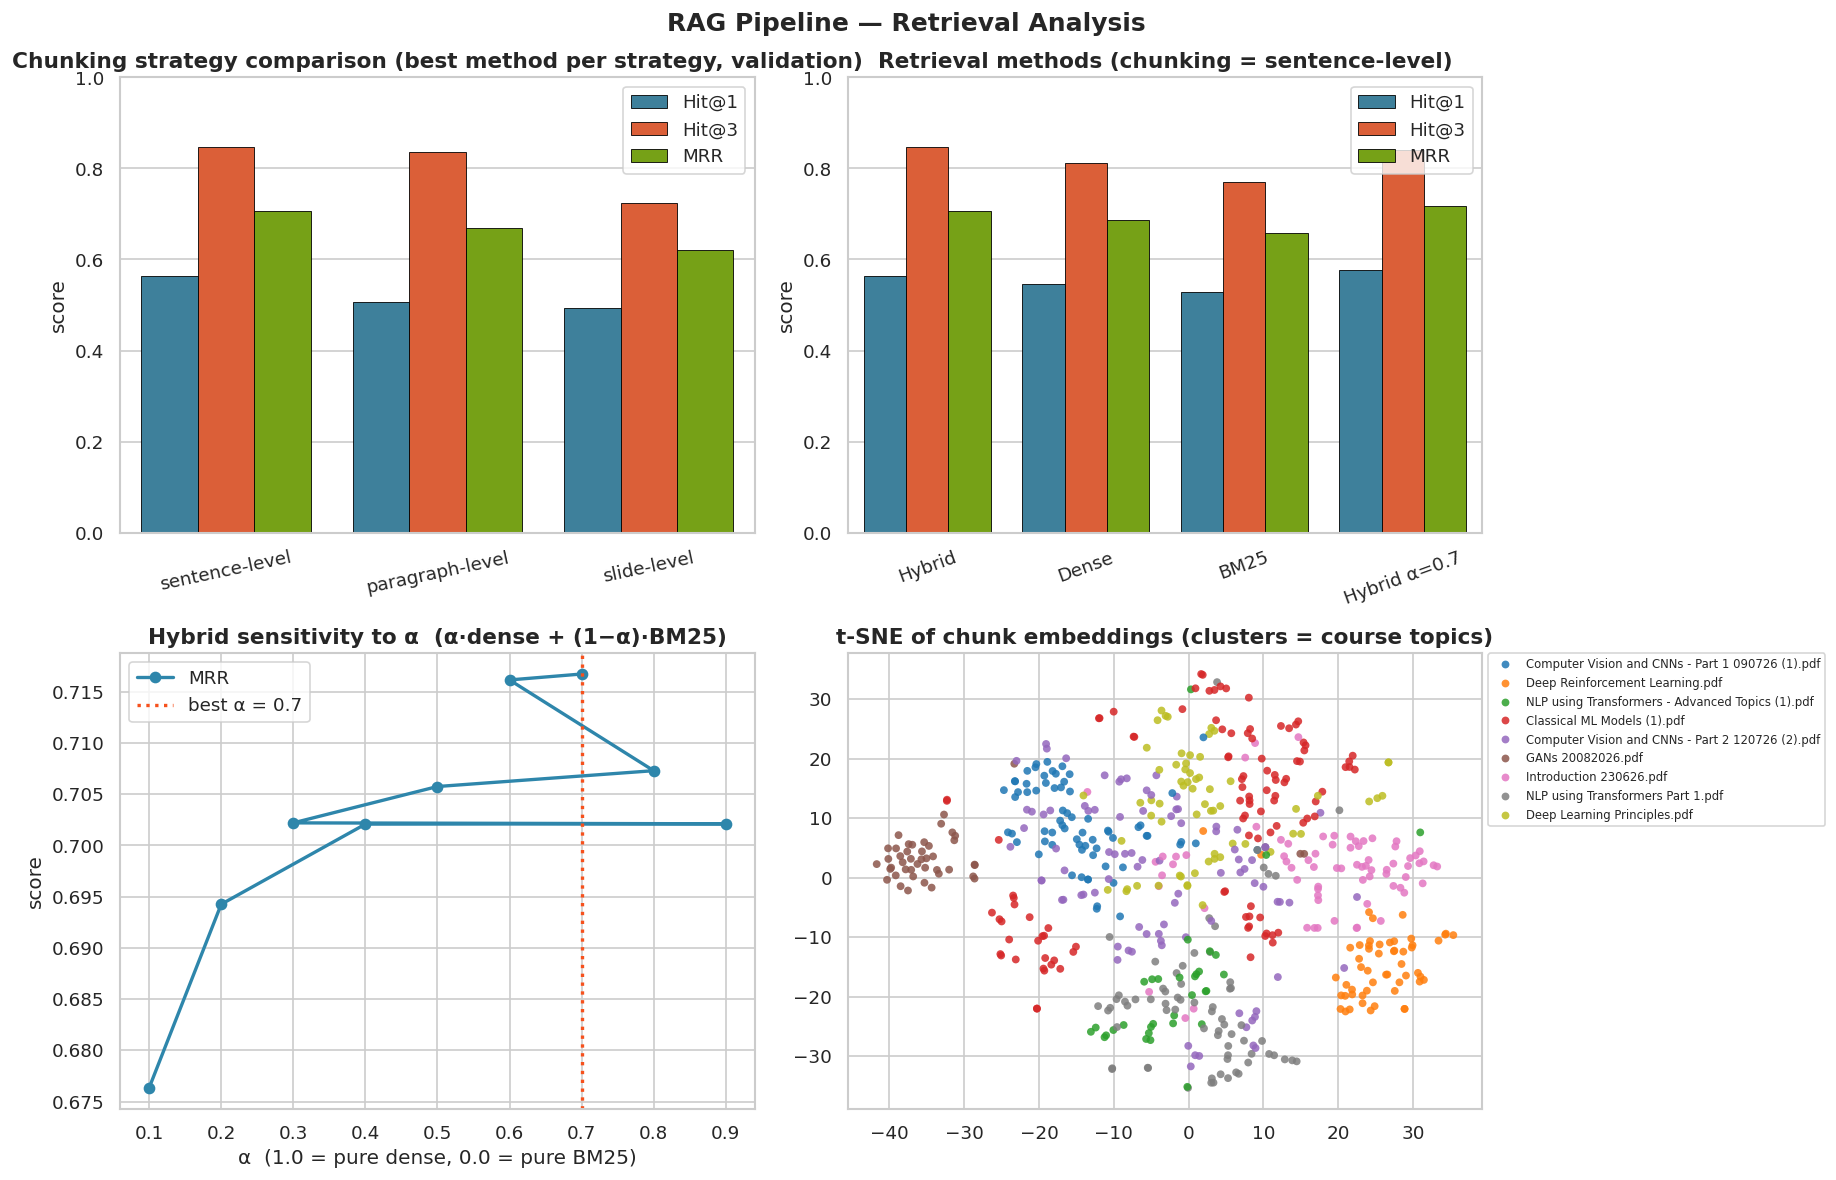

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 10 — RAG figures: chunking, retrieval methods, alpha sweep, t-SNE
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── (1) Chunking strategy comparison ──────────────────────────────────────────
chunk_plot = chunking_df.melt(id_vars="strategy", value_vars=["Hit@1", "Hit@3", "MRR"],
                              var_name="metric", value_name="score")
sns.barplot(data=chunk_plot, x="strategy", y="score", hue="metric",
            ax=axes[0, 0], palette=PALETTE[:3], edgecolor="black", linewidth=0.5)
axes[0, 0].set_title("Chunking strategy comparison (best method per strategy, validation)")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=12)
axes[0, 0].legend(title="", loc="upper right", frameon=True)

# ── (2) Retrieval method comparison ───────────────────────────────────────────
retrieval_summary = retrieval_df[
    (retrieval_df["alpha"].isna()) |
    (retrieval_df["alpha"] == best_alpha)
].copy()
retrieval_summary["label"] = retrieval_summary.apply(
    lambda r: r["method"] if pd.isna(r["alpha"]) else f"Hybrid α={r['alpha']}", axis=1)
retrieval_plot = retrieval_summary.melt(id_vars="label", value_vars=["Hit@1", "Hit@3", "MRR"],
                                        var_name="metric", value_name="score")
sns.barplot(data=retrieval_plot, x="label", y="score", hue="metric",
            ax=axes[0, 1], palette=PALETTE[:3], edgecolor="black", linewidth=0.5)
axes[0, 1].set_title(f"Retrieval methods (chunking = {best_strategy})")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].legend(title="", loc="upper right", frameon=True)

# ── (3) Alpha sensitivity ─────────────────────────────────────────────────────
axes[1, 0].plot(alpha_df["alpha"], alpha_df["MRR"], marker="o",
                color=PALETTE[0], linewidth=2, label="MRR")
axes[1, 0].axvline(best_alpha, color=PALETTE[1], linestyle=":", linewidth=2,
                   label=f"best α = {best_alpha}")
axes[1, 0].set_title("Hybrid sensitivity to α  (α·dense + (1−α)·BM25)")
axes[1, 0].set_xlabel("α  (1.0 = pure dense, 0.0 = pure BM25)")
axes[1, 0].set_ylabel("score")
axes[1, 0].legend()

# ── (4) t-SNE of the chunk embeddings, coloured by source document ────────────
sample_size = min(600, len(best_chunks))
sample_indices = np.random.RandomState(CFG.SEED).choice(
    len(best_chunks), size=sample_size, replace=False)
sample_vectors = chunk_embeddings[best_strategy][sample_indices]
sample_labels = [best_chunks[i]["source"] for i in sample_indices]

tsne = TSNE(n_components=2, perplexity=min(30, max(5, sample_size // 20)),
            init="pca", learning_rate="auto", random_state=CFG.SEED)
projection = tsne.fit_transform(sample_vectors)

tsne_df = pd.DataFrame({"x": projection[:, 0], "y": projection[:, 1], "document": sample_labels})
top_documents = tsne_df["document"].value_counts().head(9).index
tsne_df["document"] = tsne_df["document"].where(tsne_df["document"].isin(top_documents), "other")

sns.scatterplot(data=tsne_df, x="x", y="y", hue="document", ax=axes[1, 1],
                palette="tab10", s=22, alpha=0.85, edgecolor="none")
axes[1, 1].set_title("t-SNE of chunk embeddings (clusters = course topics)")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")
axes[1, 1].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1),
                  borderaxespad=0, frameon=True)

fig.suptitle("RAG Pipeline — Retrieval Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(right=0.82)
save_figure(fig, "03_rag_retrieval_analysis")
plt.show()

## Conclusion — Retrieval Analysis

**Chunking:** Sentence-level chunking wins (MRR 0.717) — shorter, focused windows reduce noise and improve rank precision; paragraph and slide chunks dilute the relevant signal with surrounding context.

**Retrieval method:** Hybrid outperforms both Dense and BM25 alone, confirming that semantic similarity and term frequency capture complementary signals — Dense handles conceptual paraphrasing, BM25 anchors on exact technical terms.

**Alpha sweep:** MRR peaks at α=0.7, meaning the retriever leans heavily on dense embeddings with BM25 as a lightweight corrector. This makes sense for course material: lecture language is consistent enough that semantic embeddings generalize well, and BM25 mainly helps when a question uses the exact slide vocabulary.

**Embedding space:** t-SNE reveals that the embedding model has learned genuine semantic structure — not just surface vocabulary. Thematically close lectures cluster together: Computer Vision Part 1 and Part 2 occupy the same region of the space, and GANs sits nearby (visual generative models share architecture and loss vocabulary with CV). Deep Reinforcement Learning separates cleanly into its own region, reflecting how distinct its concepts (reward, policy, Bellman) are from the rest of the curriculum. General ML topics (Intro, Classical ML, Deep Learning Principles, NLP) overlap in the center — reflection of shared foundations like - gradient descent and loss functions. This validates that the dense retriever is operating on a structured semantic space, not bag-of-words proximity.

## Cell 11 — Guardrails: knowing when to say "I don't know"

A study assistant that confidently invents an answer to a question outside the syllabus is worse
than useless, so the system needs an **abstention rule**:

> if `max_similarity < threshold` → *"I don't have enough information in the course material to answer this question."*

**How the threshold is chosen — not guessed:**
1. Compute the top-1 similarity for every **in-scope** validation question.
2. Compute the same for deliberately **out-of-scope** questions (cooking, football, astronomy…)
   that the course material genuinely cannot answer.
3. Sweep candidate thresholds and keep the one maximising **balanced accuracy** — answering
   in-scope questions against abstaining on out-of-scope ones.

Balanced accuracy is the right objective here: both error types are real and the two classes are
artificially balanced, so optimising raw accuracy would simply let the larger class win.


  GUARDRAIL CALIBRATION
  In-scope  top-1 similarity : mean=0.660  p05=0.462
  Out-of-scope top-1 similarity: mean=0.227  p95=0.294
  Selected threshold         : 0.330
  Answers in-scope questions : 100.0%
  Abstains out-of-scope      : 100.0%
  Balanced accuracy          : 100.0%
   figure saved: 04_guardrail_threshold.png


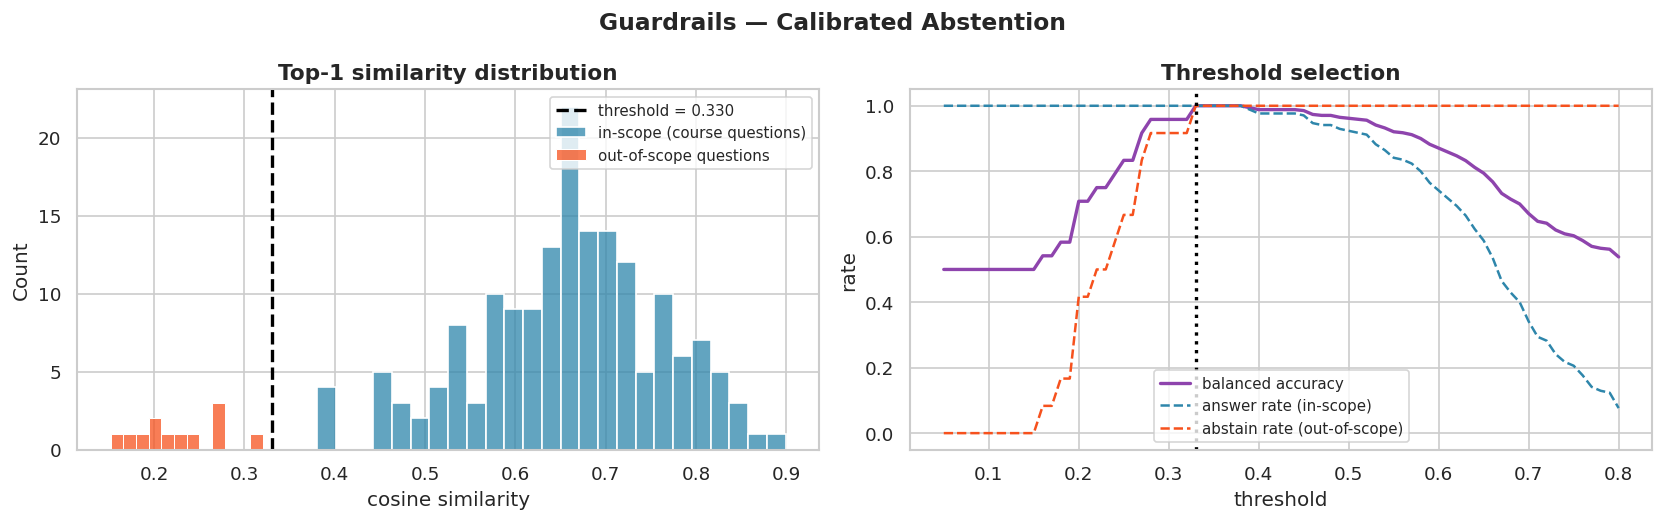

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 11 — Guardrails: the "I don't know" threshold
# ═══════════════════════════════════════════════════════════════════════════════

OUT_OF_SCOPE_QUESTIONS = [
    "What is the best way to cook a medium-rare steak?",
    "Who won the football world cup in 1998?",
    "How far is Mars from Earth in kilometres?",
    "What are the symptoms of the common cold?",
    "How do I change a flat bicycle tyre?",
    "What is the capital city of Australia?",
    "Which vitamins are found in oranges?",
    "How long does it take to fly from Tel Aviv to New York?",
    "What is the offside rule in football?",
    "How do I train a puppy not to bark at night?",
    "What is the exchange rate between the euro and the shekel?",
    "Which paint finish is best for a bathroom ceiling?",
]

ABSTENTION_MESSAGE = ("I don't have enough information in the course material "
                      "to answer this question.")


def top1_similarity(questions: List[str]) -> np.ndarray:
    """Top-1 dense cosine similarity for each question — the guardrail signal."""
    hits = [best_dense.search(question, k=1) for question in questions]
    return np.asarray([hit[0][1] if hit else 0.0 for hit in hits], dtype="float32")


in_scope_scores = top1_similarity(val_df["question"].tolist())
out_scope_scores = top1_similarity(OUT_OF_SCOPE_QUESTIONS)


def select_threshold(in_scope: np.ndarray, out_scope: np.ndarray) -> Tuple[float, pd.DataFrame]:
    """Choose the threshold maximising balanced accuracy between answering and abstaining."""
    sweep = pd.DataFrame([
        {"threshold": round(float(threshold), 3),
         "answer_rate_in_scope": float((in_scope >= threshold).mean()),      # answered
         "abstain_rate_out_of_scope": float((out_scope < threshold).mean())}  # abstained
        for threshold in np.linspace(0.05, 0.80, 76)
    ])
    sweep["balanced_accuracy"] = sweep[["answer_rate_in_scope",
                                        "abstain_rate_out_of_scope"]].mean(axis=1)
    return float(sweep.loc[sweep["balanced_accuracy"].idxmax(), "threshold"]), sweep


GUARDRAIL_THRESHOLD, threshold_sweep = select_threshold(in_scope_scores, out_scope_scores)
best_guardrail_row = threshold_sweep.loc[threshold_sweep["balanced_accuracy"].idxmax()]

section("GUARDRAIL CALIBRATION")
print(f"  In-scope  top-1 similarity : mean={in_scope_scores.mean():.3f}  "
      f"p05={np.percentile(in_scope_scores, 5):.3f}")
print(f"  Out-of-scope top-1 similarity: mean={out_scope_scores.mean():.3f}  "
      f"p95={np.percentile(out_scope_scores, 95):.3f}")
print(f"  Selected threshold         : {GUARDRAIL_THRESHOLD:.3f}")
print(f"  Answers in-scope questions : {best_guardrail_row['answer_rate_in_scope']:.1%}")
print(f"  Abstains out-of-scope      : {best_guardrail_row['abstain_rate_out_of_scope']:.1%}")
print(f"  Balanced accuracy          : {best_guardrail_row['balanced_accuracy']:.1%}")
rule()

# --- Figure: score distributions + threshold sweep -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))

sns.histplot(in_scope_scores, bins=25, ax=axes[0], color=PALETTE[0],
             label="in-scope (course questions)", alpha=0.75, edgecolor="white")
sns.histplot(out_scope_scores, bins=12, ax=axes[0], color=PALETTE[1],
             label="out-of-scope questions", alpha=0.75, edgecolor="white")
axes[0].axvline(GUARDRAIL_THRESHOLD, color="black", linestyle="--", linewidth=2,
                label=f"threshold = {GUARDRAIL_THRESHOLD:.3f}")
axes[0].set_title("Top-1 similarity distribution")
axes[0].set_xlabel("cosine similarity")
axes[0].legend(fontsize=9)

axes[1].plot(threshold_sweep["threshold"], threshold_sweep["balanced_accuracy"],
             color=PALETTE[3], linewidth=2, label="balanced accuracy")
axes[1].plot(threshold_sweep["threshold"], threshold_sweep["answer_rate_in_scope"],
             color=PALETTE[0], linestyle="--", label="answer rate (in-scope)")
axes[1].plot(threshold_sweep["threshold"], threshold_sweep["abstain_rate_out_of_scope"],
             color=PALETTE[1], linestyle="--", label="abstain rate (out-of-scope)")
axes[1].axvline(GUARDRAIL_THRESHOLD, color="black", linestyle=":", linewidth=2)
axes[1].set_title("Threshold selection")
axes[1].set_xlabel("threshold")
axes[1].set_ylabel("rate")
axes[1].legend(fontsize=9)

fig.suptitle("Guardrails — Calibrated Abstention", fontsize=14, fontweight="bold")
plt.tight_layout()
save_figure(fig, "04_guardrail_threshold")
plt.show()

## Guardrail Calibration — Results

The threshold (0.330) was **selected, not guessed**: it maximises balanced accuracy
over a sweep of candidate thresholds, evaluated against 12 out-of-scope probes
(football, cooking, astronomy...) alongside the in-scope validation questions.

**The separation is clean:** the 5th percentile of in-scope similarity (0.462) sits
well above the 95th percentile of out-of-scope similarity (0.294) — a gap of 0.168
with almost no overlap between the two distributions. This is why balanced accuracy
peaks at 100% across a fairly wide band (~0.30–0.35) rather than at one fragile point.

As the histogram shows, the two distributions form clearly separated clusters — this
is because the out-of-scope probes are topics genuinely far removed from the course
material (football, cooking, astronomy vs. machine learning and NLP), so the model
has no trouble telling them apart.

## Cell 12 — RAG Generation

The retriever finds the evidence; the reader turns it into an answer. The reader is the
**untouched** `flan-t5-base` — the same checkpoint Part B fine-tunes. Keeping it identical is
what makes the Part C comparison clean:

| System | Weights | Context at inference |
|---|---|---|
| **RAG** | frozen base model | retrieved chunks |
| **LoRA** | fine-tuned adapters | none |
| **Hybrid** | fine-tuned adapters | retrieved chunks |

Prompt wording matters for how well the reader uses the retrieved evidence, so before
running generation on the full pipeline, three prompt variants are compared on
validation and the best one (by BLEU) is selected:

- **v1** — role framing + task-first ordering: the model is told what a good answer
  looks like before it's told what to do when it doesn't know one
- **v2** — same ordering, plus explicit `<material>` delimiters around the source
  text and a length constraint
- **v3** — same as v2, plus guidance to explain the fact in its own words rather
  than copy it verbatim

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 12 — RAG Generation (retriever + frozen flan-t5-base reader)
# ═══════════════════════════════════════════════════════════════════════════════

base_tokenizer = AutoTokenizer.from_pretrained(CFG.BASE_MODEL)
base_model = AutoModelForSeq2SeqLM.from_pretrained(CFG.BASE_MODEL).to(DEVICE).eval()


@torch.no_grad()
def generate_answer(model, prompt: str) -> str:
    """Beam search with a minimum-length floor.

    Replaces greedy decoding (num_beams=1) without sacrificing reproducibility:
    do_sample=False guarantees identical output on every run. min_new_tokens
    eliminates degenerate one-token answers produced when EOS is the locally-
    optimal first token — a known failure mode of small seq2seq models on
    open-ended prompts. no_repeat_ngram_size=3 replaces the per-token
    repetition_penalty with a hard structural block on repeated trigrams.
    """
    inputs = base_tokenizer(
        prompt, return_tensors="pt", truncation=True,
        max_length=CFG.GEN_MAX_INPUT_LENGTH
    ).to(DEVICE)
    output = model.generate(
        **inputs,
        max_new_tokens=CFG.GEN_MAX_NEW_TOKENS,
        min_new_tokens=CFG.GEN_MIN_NEW_TOKENS,
        num_beams=CFG.GEN_NUM_BEAMS,
        no_repeat_ngram_size=CFG.GEN_NO_REPEAT_NGRAM,
        repetition_penalty=CFG.GEN_REPETITION_PENALTY,
        early_stopping=True,
        do_sample=CFG.GEN_DO_SAMPLE,
        pad_token_id=base_tokenizer.eos_token_id,
    )
    return base_tokenizer.decode(output[0], skip_special_tokens=True).strip()

# ── Small-to-Big context expansion ───────────────────────────────────────────
# Sentence-level chunks (avg 39 tokens) are precise retrieval units but poor
# reading units: TOP_K=3 fills only ~23% of the 512-token input budget.
# expand_to_parents replaces each retrieved chunk with its full source page,
# deduplicated and ordered for coherent reading, while respecting the budget.
# The retriever and its ranking are unchanged — only what the reader receives.

PAGE_TEXT = {
    (row["source"], int(row["page"])): str(row["text"]).strip()
    for _, row in corpus_df.iterrows()
}

def expand_to_parents(retrieved: List[Dict], token_budget: int = 400) -> str:
    """Replace retrieved chunks with their full source pages.

    Pages are collected in rank order (highest-scoring evidence first) so the
    budget cut preserves the most relevant material, then emitted in reading
    order so the model sees coherent prose. Each page is included at most once
    regardless of how many chunks pointed at it.

    token_budget is set to 400 rather than the full 512 to leave room for
    the prompt template and question (~80-100 tokens overhead).
    """
    ordered_pages, seen = [], set()
    for item in retrieved:                          # rank order
        chunk = item["chunk"]
        key = (chunk["source"], int(chunk["page_start"]))
        if key not in seen:
            seen.add(key)
            ordered_pages.append(key)

    kept, used = [], 0
    for source, page in ordered_pages:             # budget pass
        text = PAGE_TEXT.get((source, page), "")
        if not text:
            continue
        cost = len(base_tokenizer.encode(text, add_special_tokens=False))
        if used + cost > token_budget and kept:    # always keep at least one
            break
        kept.append((source, page))
        used += cost

    kept.sort(key=lambda sp: (sp[0], sp[1]))       # reading order
    return "\n\n".join(PAGE_TEXT[(s, p)] for s, p in kept)

def rag_answer(question: str, retriever=None, model=None, k: int = None,
               apply_guardrail: bool = True, use_small_to_big: bool = False) -> Dict:
    """Retrieve → guardrail → generate.
    context_builder: 'chunks' uses the raw retrieved chunks (baseline);
    'small_to_big' expands each chunk to its full source page.
    Both paths share the same retriever and ranking.
    """
    retriever = retriever or production_retriever
    model = model if model is not None else base_model
    k = k or CFG.TOP_K

    started = time.perf_counter()
    hits = retriever.search(question, k=k)
    retrieved = [{"chunk": best_chunks[i], "score": score} for i, score in hits]
    top_score = retrieved[0]["score"] if retrieved else 0.0

    dense_top = best_dense.search(question, k=1)
    guardrail_score = dense_top[0][1] if dense_top else 0.0

    if apply_guardrail and guardrail_score < GUARDRAIL_THRESHOLD:
        return {"answer": ABSTENTION_MESSAGE, "abstained": True,
                "retrieved": retrieved, "top_score": top_score,
                "guardrail_score": guardrail_score,
                "latency_s": time.perf_counter() - started}

    context = (expand_to_parents(retrieved) if USE_SMALL_TO_BIG
           else "\n\n".join(item["chunk"]["text"] for item in retrieved))
    answer = generate_answer(model, RAG_PROMPT_TEMPLATE.format(context=context, question=question))

    return {"answer": answer, "abstained": False, "retrieved": retrieved,
            "top_score": top_score, "guardrail_score": guardrail_score,
            "latency_s": time.perf_counter() - started}


# ─────────────────────────────────────────────────────────────────────────────
#  Prompt × context builder — 3×2 grid, compared on validation, selected by BLEU
#
#  Selected jointly: prompt wording and context volume interact, so optimising
#  one while holding the other.
# ─────────────────────────────────────────────────────────────────────────────

# v1 — role framing + task-first ordering. The model is told what a good answer
# looks like before it is told what to do when it doesn't know one.
PROMPT_V1_ROLE_TASK = (
    "You are a teaching assistant for a university course on applied language models. "
    "Using only the course material below, answer the question in one complete, "
    "well-formed sentence. Explain the concept rather than simply naming it.\n\n"
    "If the material does not contain the answer, reply exactly: I do not know.\n\n"
    "Course material:\n{context}\n\n"
    "Question: {question}\n"
    "Answer:"
)

# v2 — same ordering and role, plus explicit delimiters around the source text and
# an explicit length constraint, so the model has a hard boundary between "material
# to read" and "question to answer".
PROMPT_V2_DELIMITED = (
    "You are a teaching assistant for a university course on applied language models. "
    "Answer the question in one to two complete sentences, using only the material "
    "inside the <material> tags. Explain the concept in your own words.\n\n"
    "If the material does not contain the answer, reply exactly: I do not know.\n\n"
    "<material>\n{context}\n</material>\n\n"
    "Question: {question}\n"
    "Answer:"
)

# v3 — adds a guidance cue that separates finding the relevant fact from explaining
# it, encouraging paraphrase over verbatim copying, without turning this into a
# multi-step / chain-of-thought prompt (a single deterministic generate() call).
PROMPT_V3_GUIDED = (
    "You are a teaching assistant for a university course on applied language models. "
    "First identify the fact in the material below that answers the question, then "
    "explain it in your own words as one complete sentence. Do not copy sentences "
    "verbatim from the material.\n\n"
    "If the material does not contain the answer, reply exactly: I do not know.\n\n"
    "<material>\n{context}\n</material>\n\n"
    "Question: {question}\n"
    "Answer:"
)

PROMPT_VARIANTS = {
    "v1_role_task":   PROMPT_V1_ROLE_TASK,
    "v2_delimited":   PROMPT_V2_DELIMITED,
    "v3_guided":      PROMPT_V3_GUIDED,
}

# ── Prompt × Context Builder grid (3 × 2 = 6 combinations) ───────────────────
section("PROMPT × CONTEXT BUILDER — 3×2 grid (validation, selected by BLEU)")

CONTEXT_BUILDERS = {
    "chunks":       lambda r: "\n\n".join(item["chunk"]["text"] for item in r),
    "small_to_big": lambda r: expand_to_parents(r),
}

val_sample = val_df.sample(
    n=min(100, len(val_df)), random_state=CFG.SEED
).to_dict("records")

grid_results = []

for prompt_name, template in PROMPT_VARIANTS.items():
    for builder_name, builder_fn in CONTEXT_BUILDERS.items():
        predictions, references = [], []

        for qa in tqdm(val_sample, desc=f"{prompt_name} × {builder_name}"):
            hits      = production_retriever.search(qa["question"], k=CFG.TOP_K)
            retrieved = [{"chunk": best_chunks[i], "score": s} for i, s in hits]
            context   = builder_fn(retrieved)
            answer    = generate_answer(
                base_model,
                template.format(context=context, question=qa["question"])
            )
            predictions.append(answer)
            references.append(qa["answer"])

        rouge = rouge_metric.compute(
            predictions=predictions, references=references, use_stemmer=True
        )
        bleu = bleu_metric.compute(
            predictions=predictions, references=[[r] for r in references]
        )
        grid_results.append({
            "prompt":          prompt_name,
            "context_builder": builder_name,
            "BLEU":            round(float(bleu["score"]) / 100, 4),
            "ROUGE-L":         round(float(rouge["rougeL"]), 4),
            "avg_tokens":      round(np.mean([
                len(base_tokenizer.encode(p, add_special_tokens=False))
                for p in predictions
            ]), 1),
        })

grid_df = pd.DataFrame(grid_results).sort_values("ROUGE-L", ascending=False)
display(grid_df)

# ── Selection ──────────────────────────────────────────────────────────────────
best_row          = grid_df.iloc[0]
best_prompt_name  = best_row["prompt"]
best_builder_name = best_row["context_builder"]

RAG_PROMPT_TEMPLATE = PROMPT_VARIANTS[best_prompt_name]
USE_SMALL_TO_BIG    = (best_builder_name == "small_to_big")

print(f"\n  Winner: prompt={best_prompt_name}, context={best_builder_name}")
print(f"  BLEU={best_row['BLEU']:.4f}   ROUGE-L={best_row['ROUGE-L']:.4f}")
rule()


# --- Qualitative check on validation questions ------------------------------------
section("RAG GENERATION — qualitative check (validation set)")

rag_preview_rows = []
for _, row in val_df.sample(n=min(5, len(val_df)), random_state=CFG.SEED).iterrows():
    result = rag_answer(row["question"])
    top_chunk = result["retrieved"][0]["chunk"] if result["retrieved"] else None
    rag_preview_rows.append({
        "question": row["question"],
        "gold_answer": row["answer"],
        "rag_answer": result["answer"],
        "top_score": round(result["top_score"], 3),
        "retrieved_from": f"{top_chunk['source'][:20]} p.{top_chunk['page_start']}" if top_chunk else "-",
        "abstained": result["abstained"],
    })

display(pd.DataFrame(rag_preview_rows))

# --- Guardrail behaviour on an out-of-scope question -------------------------------
out_of_scope_demo = rag_answer("Who won the football world cup in 1998?")
print(f"\n  Out-of-scope probe -> abstained = {out_of_scope_demo['abstained']}")
print(f"  System reply       : {out_of_scope_demo['answer']}")
rule()

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

v3_guided × small_to_big:   0%|          | 0/100 [00:00<?, ?it/s]

,prompt,context_builder,BLEU,ROUGE-L,avg_tokens
0,v1_role_task,chunks,0.2262,0.4147,20.8
2,v2_delimited,chunks,0.2178,0.4064,21.2
5,v3_guided,small_to_big,0.2095,0.4010,21.8
4,v3_guided,chunks,0.2088,0.3984,21.8
3,v2_delimited,small_to_big,0.2097,0.3972,21.1
1,v1_role_task,small_to_big,0.1999,0.3919,19.7



  Winner: prompt=v1_role_task, context=chunks
  BLEU=0.2262   ROUGE-L=0.4147

  RAG GENERATION — qualitative check (validation set)


,question,gold_answer,rag_answer,top_score,retrieved_from,abstained
0,What is the core architecture of a Siamese net...,A Siamese network consists of two identical su...,"""signature verification using a"" siamese"" time...",1.000,Computer Vision and p.22,False
1,What is a concrete example of resizing images ...,Resizing images to 224x224 pixels for input in...,resizing images to 224x224 pixels for input in...,1.000,Computer Vision and p.47,False
2,Why can understanding the decision-making proc...,It is often unclear how specific examples infl...,many generative models exhibit stochastic beha...,1.000,GANs 20082026.pdf p.2,False
3,"Who authored the paper introducing CLIP, and i...",The paper was authored by Alec Radford and oth...,coursera artificial intelligence and deep lear...,0.804,Deep Learning Princi p.65,False
4,Who are the notable figures mentioned in conne...,"Fei-Fei Li is associated with ImageNet, and Ya...","Fei-fei li (imagenet), yann lecun",1.000,Computer Vision and p.2,False



  Out-of-scope probe -> abstained = True
  System reply       : I don't have enough information in the course material to answer this question.


## Cell 13 — Saving the RAG Artefacts

The retrieval half of the project is finished and reproducible. Persisted here:

| File | Purpose |
|---|---|
| `chunks.json` | the selected chunk set with full provenance |
| `faiss_index.bin` | the exact vector index, so it never has to be rebuilt |
| `chunk_embeddings.npy` | the embedding matrix, for the t-SNE figure and further analysis |
| `rag_results.json` | every retrieval experiment: chunking, methods, α sweep, guardrail |

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 13 — Persist the RAG artefacts to Drive
# ═══════════════════════════════════════════════════════════════════════════════

rag_results = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "selected": {
        "chunking_strategy": best_strategy,
        "retrieval_method": best_method,
        "alpha": best_alpha if best_method == "hybrid" else None,
        "top_k": CFG.TOP_K,
        "guardrail_threshold": round(float(GUARDRAIL_THRESHOLD), 4),
    },
    "chunking_experiment": chunking_df.to_dict(orient="records"),
    "retrieval_experiment": retrieval_df.to_dict(orient="records"),
    "alpha_sweep": alpha_df.to_dict(orient="records"),
    "guardrail": {
        "balanced_accuracy": float(best_guardrail_row["balanced_accuracy"]),
        "answer_rate_in_scope": float(best_guardrail_row["answer_rate_in_scope"]),
        "abstain_rate_out_of_scope": float(best_guardrail_row["abstain_rate_out_of_scope"]),
    },
}

(CFG.data_dir / "chunks.json").write_text(
    json.dumps(best_chunks, ensure_ascii=False, indent=2), encoding="utf-8")
faiss.write_index(faiss_indexes[best_strategy], str(CFG.data_dir / "faiss_index.bin"))
np.save(CFG.data_dir / "chunk_embeddings.npy", chunk_embeddings[best_strategy])
(CFG.results_dir / "rag_results.json").write_text(
    json.dumps(rag_results, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

section("RAG ARTEFACTS SAVED")
print(f"   chunks.json            ({len(best_chunks):,} chunks, strategy = {best_strategy})")
print(f"   faiss_index.bin        ({faiss_indexes[best_strategy].ntotal:,} vectors)")
print(f"   chunk_embeddings.npy   {chunk_embeddings[best_strategy].shape}")
print(f"   rag_results.json       (all retrieval experiments)")
rule()


  RAG ARTEFACTS SAVED
   chunks.json            (1,407 chunks, strategy = sentence-level)
   faiss_index.bin        (1,407 vectors)
   chunk_embeddings.npy   (1407, 384)
   rag_results.json       (all retrieval experiments)


---
# PART B — LoRA Fine-Tuning
---

## Cell 14 — Base Model, LoRA Configuration & the

`target_modules=["q","v"]` — Hu et al. (2021) showed that adapting query and value projections
alone matches full attention fine-tuning; adding `k` and `o` costs parameters for negligible gain.
Fixing this also keeps the coordinate search clean — one factor moves at a time.

`run_lora_experiment(...)` is the single entry point for every run. Config, BLEU, ROUGE-L,
training curve and runtime land in one shared table — 15 comparable runs, not 15 console dumps.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 14 — Base model, LoRA configuration and the experiment harness
# ═══════════════════════════════════════════════════════════════════════════════


INSTRUCTION_PREFIX = "answer the course question: "


# ───────────────────────────────────────────────────────────────────────────────
#  Tokenization schemes
# ───────────────────────────────────────────────────────────────────────────────
# All three schemes ultimately feed the T5 vocabulary; what changes is the
# *input segmentation* presented to the model:
#   word    : explicit word boundaries (NLTK), so the subword tokenizer sees whole words
#   subword : the native flan-t5 SentencePiece segmentation (the baseline)
#   char    : characters separated by spaces, forcing near-character-level granularity
def segment_word(text: str) -> str:
    """Explicit word-level segmentation with NLTK."""
    return " ".join(word_tokenize(text))


def segment_subword(text: str) -> str:
    """Native flan-t5 subword segmentation — the text is passed through untouched."""
    return text


def segment_char(text: str) -> str:
    """Character-level segmentation: every character becomes its own unit."""
    return " ".join(list(text))


SEGMENTERS: Dict[str, Callable[[str], str]] = {
    "word": segment_word,
    "subword": segment_subword,
    "char": segment_char,
}


# ───────────────────────────────────────────────────────────────────────────────
#  LoRA configuration factory — one definition, used by the search and the probe
# ───────────────────────────────────────────────────────────────────────────────
def build_lora_config(r: int, lora_alpha: int, lora_dropout: float) -> LoraConfig:
    """The plan's LoRA setup, with only the three searched knobs left open."""
    return LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        target_modules=list(CFG.LORA_TARGET_MODULES),
        bias="none",
        inference_mode=False,
    )


# ───────────────────────────────────────────────────────────────────────────────
#  Dataset construction
# ───────────────────────────────────────────────────────────────────────────────
def build_hf_dataset(df: pd.DataFrame, segmenter: Callable[[str], str],
                     tokenizer) -> Dataset:
    """Tokenise a split into a HuggingFace Dataset ready for Seq2SeqTrainer."""
    sources = [INSTRUCTION_PREFIX + segmenter(q) for q in df["question"]]
    targets = list(df["answer"])

    model_inputs = tokenizer(sources, max_length=CFG.MAX_SOURCE_LENGTH,
                             truncation=True, padding=False)
    labels = tokenizer(text_target=targets, max_length=CFG.MAX_TARGET_LENGTH,
                       truncation=True, padding=False)
    model_inputs["labels"] = labels["input_ids"]
    return Dataset.from_dict(model_inputs)


def count_trainable_parameters(model) -> Tuple[int, int, float]:
    """Return (trainable, total, percentage) — the proof that only LoRA is training."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total, 100 * trainable / total


# ───────────────────────────────────────────────────────────────────────────────
#  The experiment harness
# ───────────────────────────────────────────────────────────────────────────────
EXPERIMENT_LOG: List[Dict] = []


def run_lora_experiment(run_name: str, stage: str, tokenization: str,
                        r: int, lora_alpha: int, lora_dropout: float,
                        train_frame: pd.DataFrame, eval_frame: pd.DataFrame,
                        keep_model: bool = False):
    """Train one LoRA configuration and evaluate ROUGE-L on the validation subset.

    Returns the metrics dictionary; the trained model is returned only when
    `keep_model=True` (used for the final winning configuration) so that GPU memory
    is released between the many search runs.
    """
    set_global_seed(CFG.SEED)                       # identical initialisation every run

    tokenizer = AutoTokenizer.from_pretrained(CFG.BASE_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(CFG.BASE_MODEL)

    model = get_peft_model(model, build_lora_config(r, lora_alpha, lora_dropout))
    trainable, total, trainable_pct = count_trainable_parameters(model)

    segmenter = SEGMENTERS[tokenization]
    train_dataset = build_hf_dataset(train_frame, segmenter, tokenizer)
    eval_dataset = build_hf_dataset(eval_frame, segmenter, tokenizer)

    collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)

    def compute_metrics(eval_prediction):
        """Two evaluation metrics computed on the validation subset each epoch.

        ROUGE-L selects the best checkpoint (metric_for_best_model).
        BLEU is reported alongside to verify both metrics rank configurations consistently.
        """
        predictions, labels = eval_prediction
        if isinstance(predictions, tuple):
           predictions = predictions[0]
        predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
        labels      = np.where(labels      != -100, labels,      tokenizer.pad_token_id)
        decoded_predictions = tokenizer.batch_decode(predictions, skip_special_tokens=True)
        decoded_labels      = tokenizer.batch_decode(labels,      skip_special_tokens=True)
        rouge = rouge_metric.compute(predictions=decoded_predictions,
                                    references=decoded_labels, use_stemmer=True)
        bleu  = bleu_metric.compute(predictions=decoded_predictions,
                                    references=[[l] for l in decoded_labels])
        return {
            "rougeL": float(rouge["rougeL"]),
            "rouge1": float(rouge["rouge1"]),
            "bleu":   round(float(bleu["score"]) / 100, 4),}

    training_arguments = Seq2SeqTrainingArguments(
        output_dir=f"/content/lora_runs/{run_name}",
        num_train_epochs=CFG.EPOCHS,
        per_device_train_batch_size=CFG.BATCH_SIZE,
        per_device_eval_batch_size=CFG.BATCH_SIZE,
        learning_rate=CFG.LEARNING_RATE,
        warmup_steps=CFG.WARMUP_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,               # keep the best epoch, not the last
        metric_for_best_model="rougeL",
        greater_is_better=True,
        predict_with_generate=True,
        generation_max_length=CFG.MAX_TARGET_LENGTH,
        logging_strategy="epoch",
        report_to="none",
        fp16=False,                                # T5 is numerically unstable in fp16
        seed=CFG.SEED,
        disable_tqdm=False,
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_arguments,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=CFG.EARLY_STOPPING_PATIENCE)],
    )

    started = time.perf_counter()
    trainer.train()
    training_minutes = (time.perf_counter() - started) / 60

    evaluation = trainer.evaluate()

    record = {
        "run_name": run_name,
        "stage": stage,
        "tokenization": tokenization,
        "r": r,
        "lora_alpha": lora_alpha,
        "lora_dropout": lora_dropout,
        "rougeL": round(float(evaluation.get("eval_rougeL", 0.0)), 4),
        "rouge1": round(float(evaluation.get("eval_rouge1", 0.0)), 4),
        "bleu":   round(float(evaluation.get("eval_bleu",   0.0)), 4),  # NEW
        "eval_loss": round(float(evaluation.get("eval_loss", np.nan)), 4),
        "trainable_params": trainable,
        "total_params": total,
        "trainable_pct": round(trainable_pct, 3),
        "train_minutes": round(training_minutes, 2),
        "log_history": trainer.state.log_history,
    }
    EXPERIMENT_LOG.append(record)

    print(f"   {run_name:<28} ROUGE-L={record['rougeL']:.4f}  "
      f"BLEU={record['bleu']:.4f}  "
      f"loss={record['eval_loss']:.4f}  {training_minutes:.1f} min")

    if keep_model:
        return record, trainer, tokenizer

    # Free the GPU before the next run — 15 runs in one session leave no slack.
    del trainer, model
    gc.collect()
    torch.cuda.empty_cache()
    return record


# --- Search data: full train set, validation subset for speed ----------------------
search_val_df = val_df.sample(n=min(CFG.SEARCH_VAL_SUBSET, len(val_df)),
                              random_state=CFG.SEED).reset_index(drop=True)

# --- Report the parameter efficiency of the default configuration -------------------
probe_model = get_peft_model(
    AutoModelForSeq2SeqLM.from_pretrained(CFG.BASE_MODEL),
    build_lora_config(CFG.DEFAULT_R, CFG.DEFAULT_ALPHA, CFG.DEFAULT_DROPOUT),
)
probe_trainable, probe_total, probe_pct = count_trainable_parameters(probe_model)
del probe_model
gc.collect()
torch.cuda.empty_cache()

section("LoRA PARAMETER EFFICIENCY (r=8, alpha=16, target_modules=['q','v'])")
print(f"  Total parameters     : {probe_total:,}")
print(f"  Trainable parameters : {probe_trainable:,}")
print(f"  Trainable percentage : {probe_pct:.3f}%")
print(f"  Frozen               : {100 - probe_pct:.3f}%")
print(f"  Training examples    : {len(train_df):,}   |   search validation: {len(search_val_df)}")
rule()

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.



  LoRA PARAMETER EFFICIENCY (r=8, alpha=16, target_modules=['q','v'])
  Total parameters     : 248,462,592
  Trainable parameters : 884,736
  Trainable percentage : 0.356%
  Frozen               : 99.644%
  Training examples    : 792   |   search validation: 100


## Cell 15 — Sequential Search, Stage A: Tokenization (3 runs)

**Coordinate-wise search** fixes one factor at a time at the best value found so far:

| Stage | What varies | Selection criterion | Runs |
|---|---|---|---|
| A | tokenization (word / subword / char) | ROUGE-L on validation | 3 |
| B | `r` ∈ {4, 8, 16} | ROUGE-L on validation | 3 |
| C | `lora_alpha` ∈ {8, 16, 32} | ROUGE-L on validation | 3 |
| D | `lora_dropout` ∈ {0.05, 0.1} | validation loss | 2 |
| | | **total** | **11** |



In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 15 — Sequential search, Stage A: tokenization
# ═══════════════════════════════════════════════════════════════════════════════

section("STAGE A — TOKENIZATION COMPARISON (3 runs)",
        f"Fixed: r={CFG.DEFAULT_R}, alpha={CFG.DEFAULT_ALPHA}, dropout={CFG.DEFAULT_DROPOUT}")

for tokenization in CFG.TOKENIZATIONS:
    run_lora_experiment(
        run_name=f"A_tokenization_{tokenization}",
        stage="A_tokenization",
        tokenization=tokenization,
        r=CFG.DEFAULT_R,
        lora_alpha=CFG.DEFAULT_ALPHA,
        lora_dropout=CFG.DEFAULT_DROPOUT,
        train_frame=train_df,
        eval_frame=search_val_df,
    )

stage_a_df = pd.DataFrame([r for r in EXPERIMENT_LOG if r["stage"] == "A_tokenization"])
BEST_TOKENIZATION = stage_a_df.loc[stage_a_df["rougeL"].idxmax(), "tokenization"]

section("STAGE A RESULTS")
display(stage_a_df[["tokenization", "rougeL", "rouge1", "eval_loss", "train_minutes"]])
print(f"  Selected tokenization: {BEST_TOKENIZATION}")
rule()


  STAGE A — TOKENIZATION COMPARISON (3 runs)
  Fixed: r=8, alpha=16, dropout=0.1


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,3.110089,2.598460,0.249766,0.287811,0.051100
2,2.870313,2.545284,0.251444,0.291106,0.052300
3,2.831492,2.536532,0.252972,0.290825,0.054500


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
2.831492,2.536532,3,0.252972,0.290825,0.054500


...

Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,4.055101,3.374714,0.117982,0.139197,0.002200
2,3.621542,3.288545,0.116470,0.136032,0.005300
3,3.551871,3.274230,0.128655,0.153603,0.005000


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
3.551871,3.274230,3,0.128655,0.153603,0.005000


   A_tokenization_char          ROUGE-L=0.1287  BLEU=0.0050  loss=3.2742  4.0 min

  STAGE A RESULTS


,tokenization,rougeL,rouge1,eval_loss,train_minutes
0,word,0.2530,0.2908,2.5365,2.25
1,subword,0.2521,0.2946,2.5411,2.29
2,char,0.1287,0.1536,3.2742,4.04


  Selected tokenization: word


## Cell 16 — Tokenization Comparison Figure

Quality **and** cost, side by side. A tokenization that wins by 0.002 ROUGE-L while tripling
sequence length is not a win but a bad trade, and the plot is what makes that visible.

   figure saved: 05_lora_tokenization.png


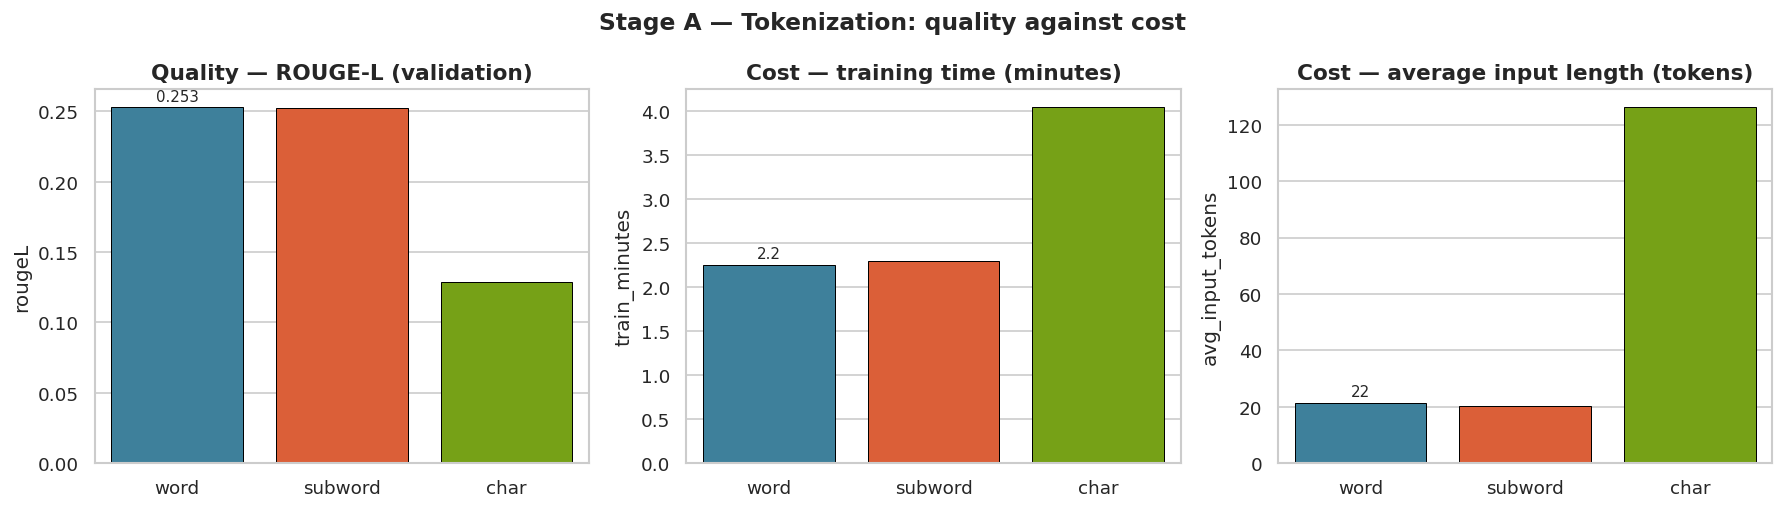

,tokenization,rougeL,train_minutes,avg_input_tokens,p95_input_tokens,truncated_pct
0,word,0.2530,2.25,21.5,31,0.0
1,subword,0.2521,2.29,20.4,29,0.0
2,char,0.1287,4.04,126.2,178,0.0


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 16 — Figure: tokenization comparison (quality vs cost)
# ═══════════════════════════════════════════════════════════════════════════════

# Measure the sequence-length cost each scheme imposes on the encoder.
sample_questions = train_df["question"].head(200).tolist()


def input_lengths(segmenter: Callable[[str], str]) -> np.ndarray:
    """Encoder input length of every sample question under one segmentation scheme."""
    return np.array([len(base_tokenizer.encode(INSTRUCTION_PREFIX + segmenter(q),
                                               add_special_tokens=False))
                     for q in sample_questions])


measured_lengths = {name: input_lengths(segmenter)
                    for name, segmenter in SEGMENTERS.items()}

length_df = pd.DataFrame([
    {"tokenization": name,
     "avg_input_tokens": round(float(lengths.mean()), 1),
     "p95_input_tokens": int(np.percentile(lengths, 95)),
     "truncated_pct": round(100 * float((lengths > CFG.MAX_SOURCE_LENGTH).mean()), 1)}
    for name, lengths in measured_lengths.items()
])
tokenization_df = stage_a_df.merge(length_df, on="tokenization")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

# One quality panel and two cost panels, drawn from the same specification.
panels = [("rougeL", "Quality — ROUGE-L (validation)", "%.3f"),
          ("train_minutes", "Cost — training time (minutes)", "%.1f"),
          ("avg_input_tokens", "Cost — average input length (tokens)", "%.0f")]

for ax, (column, title, number_format) in zip(axes, panels):
    sns.barplot(data=tokenization_df, x="tokenization", y=column, hue="tokenization",
                ax=ax, palette=PALETTE[:3], legend=False,
                edgecolor="black", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.bar_label(ax.containers[0], fmt=number_format, padding=2, fontsize=9)

fig.suptitle("Stage A — Tokenization: quality against cost", fontsize=14, fontweight="bold")
plt.tight_layout()
save_figure(fig, "05_lora_tokenization")
plt.show()

display(tokenization_df[["tokenization", "rougeL", "train_minutes",
                         "avg_input_tokens", "p95_input_tokens", "truncated_pct"]])

## Results & Conclusions— Tokenization
Three segmentation schemes at identical hyperparameters; only the input representation changes.

Word and subword segmentation are statistically indistinguishable on ROUGE-L (0.2530 vs 0.2521) —
the T5 vocabulary handles both well, and the 0.0009 gap is within validation noise.

Character-level tokenization is included as a controlled baseline rather than a serious
candidate: it expands average input length 6× while halving ROUGE-L, confirming that
technical terms like `LoRA` or `ROUGE-L` cannot survive character-level fragmentation.
The value is in the number, not the direction — the 50% degradation quantifies the cost
of losing term identity, which is the upper bound on what tokenization alone can affect.

## Cell 17 — Stage B: LoRA rank `r` (3 runs)

`r` is the rank of the low-rank update — the *capacity* of the adapter. Too small and the adapter
cannot represent the task; too large and it starts to memorise a 700-example dataset while the
parameter count grows linearly.

Tokenization is now fixed at the Stage A winner; only `r` moves.

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 17 — Sequential search, Stage B: LoRA rank r
# ═══════════════════════════════════════════════════════════════════════════════

section("STAGE B — LoRA RANK r (3 runs)",
        f"Fixed: tokenization={BEST_TOKENIZATION}, alpha={CFG.DEFAULT_ALPHA}, dropout={CFG.DEFAULT_DROPOUT}")

for r_value in CFG.LORA_R_VALUES:
    run_lora_experiment(
        run_name=f"B_rank_r{r_value}",
        stage="B_rank",
        tokenization=BEST_TOKENIZATION,
        r=r_value,
        lora_alpha=CFG.DEFAULT_ALPHA,
        lora_dropout=CFG.DEFAULT_DROPOUT,
        train_frame=train_df,
        eval_frame=search_val_df,
    )

stage_b_df = pd.DataFrame([r for r in EXPERIMENT_LOG if r["stage"] == "B_rank"])
BEST_R = int(stage_b_df.loc[stage_b_df["rougeL"].idxmax(), "r"])

section("STAGE B RESULTS")
display(stage_b_df[["r", "rougeL", "eval_loss", "trainable_params", "trainable_pct",
                    "train_minutes"]])
print(f"  Selected rank: r = {BEST_R}")
rule()


  STAGE B — LoRA RANK r (3 runs)
  Fixed: tokenization=word, alpha=16, dropout=0.1


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,3.108929,2.598339,0.247722,0.285781,0.043600
2,2.870195,2.545597,0.245073,0.283952,0.051300
3,2.833536,2.536988,0.248446,0.288559,0.052000


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
2.833536,2.536988,3,0.248446,0.288559,0.052000


...

Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,3.109938,2.600326,0.246991,0.285880,0.046900
2,2.870380,2.545913,0.243921,0.283594,0.051900
3,2.831611,2.537191,0.244072,0.283925,0.049900


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
2.831611,2.600326,3,0.246991,0.285880,0.046900


   B_rank_r16                   ROUGE-L=0.2470  BLEU=0.0469  loss=2.6003  2.2 min

  STAGE B RESULTS


,r,rougeL,eval_loss,trainable_params,trainable_pct,train_minutes
0,4,0.2484,2.5370,442368,0.178,2.26
1,8,0.2530,2.5365,884736,0.356,2.45
2,16,0.2470,2.6003,1769472,0.710,2.20


  Selected rank: r = 8


## Cell 18 — Stage C: `lora_alpha` (3 runs) + completing the `r × alpha` grid

`lora_alpha` sets the scaling of the LoRA update: the adapter contributes
$\frac{\alpha}{r} \cdot BA$. So `alpha` and `r` are **not independent** — what matters is their
ratio, which is where the common `alpha = 2r` heuristic comes from.

Since this is the one place an interaction effect is genuinely expected, the cell does two things:
1. **Stage C** varies `alpha` at the winning `r` — 3 runs, the plan's sequential budget.
2. **Grid completion** then fills the remaining `r × alpha` cells (+4 runs, switched by
   `CFG.FILL_HEATMAP_GRID`), so every cell of the Cell 20 heatmap is **measured** rather than
   interpolated.

Total: 11 sequential runs + 4 grid-completion runs = **15**, against 54 for a full grid.
Setting `FILL_HEATMAP_GRID = False` keeps strictly to the 11-run budget.

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 18 — Sequential search, Stage C: lora_alpha (+ optional grid completion)
# ═══════════════════════════════════════════════════════════════════════════════

section("STAGE C — LoRA ALPHA (3 runs)",
        f"Fixed: tokenization={BEST_TOKENIZATION}, r={BEST_R}, dropout={CFG.DEFAULT_DROPOUT}")

for alpha_value in CFG.LORA_ALPHA_VALUES:
    run_lora_experiment(
        run_name=f"C_alpha_{alpha_value}",
        stage="C_alpha",
        tokenization=BEST_TOKENIZATION,
        r=BEST_R,
        lora_alpha=alpha_value,
        lora_dropout=CFG.DEFAULT_DROPOUT,
        train_frame=train_df,
        eval_frame=search_val_df,
    )

stage_c_df = pd.DataFrame([r for r in EXPERIMENT_LOG if r["stage"] == "C_alpha"])
BEST_ALPHA = int(stage_c_df.loc[stage_c_df["rougeL"].idxmax(), "lora_alpha"])

section("STAGE C RESULTS")
display(stage_c_df[["lora_alpha", "r", "rougeL", "eval_loss", "train_minutes"]])
print(f"  Selected alpha: {BEST_ALPHA}   (alpha/r ratio = {BEST_ALPHA / BEST_R:.1f})")
rule()

# ─── Grid completion: measure every remaining (r, alpha) cell ──────────────────
if CFG.FILL_HEATMAP_GRID:
    measured_cells = {(row["r"], row["lora_alpha"]) for row in EXPERIMENT_LOG
                      if row["stage"] in ("B_rank", "C_alpha")}
    missing_cells = [(r_value, alpha_value)
                     for r_value in CFG.LORA_R_VALUES
                     for alpha_value in CFG.LORA_ALPHA_VALUES
                     if (r_value, alpha_value) not in measured_cells]

    section(f"GRID COMPLETION — {len(missing_cells)} additional runs for the r×alpha heatmap")

    for r_value, alpha_value in missing_cells:
        run_lora_experiment(
            run_name=f"G_grid_r{r_value}_a{alpha_value}",
            stage="grid_fill",
            tokenization=BEST_TOKENIZATION,
            r=r_value,
            lora_alpha=alpha_value,
            lora_dropout=CFG.DEFAULT_DROPOUT,
            train_frame=train_df,
            eval_frame=search_val_df,
        )
    print(f"  Grid complete: {len(CFG.LORA_R_VALUES) * len(CFG.LORA_ALPHA_VALUES)} cells measured.")
    # Override coordinate search with the grid winner —
    # the r×alpha interaction makes joint selection necessary.
    grid_df = pd.DataFrame([r for r in EXPERIMENT_LOG
                        if r["stage"] in ("B_rank", "C_alpha", "grid_fill")])
    best_grid_row = grid_df.loc[grid_df["rougeL"].idxmax()]
    BEST_R     = int(best_grid_row["r"])
    BEST_ALPHA = int(best_grid_row["lora_alpha"])
    print(f"  Grid winner: r={BEST_R}, alpha={BEST_ALPHA} "
    f"(ROUGE-L={best_grid_row['rougeL']:.4f})")


  STAGE C — LoRA ALPHA (3 runs)
  Fixed: tokenization=word, r=8, dropout=0.1


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,3.141431,2.626810,0.249557,0.292248,0.054100
2,2.908346,2.569532,0.241199,0.281545,0.046400
3,2.870966,2.558198,0.241282,0.279628,0.048300


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
2.870966,2.626810,3,0.249557,0.292248,0.054100


...

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,3.078264,2.574574,0.245193,0.283130,0.048900
2,2.836896,2.525472,0.256686,0.297635,0.059100
3,2.792303,2.518193,0.250211,0.287641,0.054500


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
2.792303,2.525472,3,0.256686,0.297635,0.059100


   G_grid_r16_a32               ROUGE-L=0.2567  BLEU=0.0591  loss=2.5255  2.6 min
  Grid complete: 9 cells measured.
  Grid winner: r=8, alpha=32 (ROUGE-L=0.2587)


## Cell 19 — Stage D: `lora_dropout` (2 runs)

Dropout inside the adapter is the main regulariser available on a small training set.
This stage is selected on **validation loss** rather than ROUGE-L: loss is
the more sensitive signal for over-fitting, and by this point in the search the ROUGE gap between
two dropout values is usually inside the noise.

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 19 — Sequential search, Stage D: lora_dropout (selected on validation loss)
# ═══════════════════════════════════════════════════════════════════════════════

section("STAGE D — LoRA DROPOUT (2 runs)",
        f"Fixed: tokenization={BEST_TOKENIZATION}, r={BEST_R}, alpha={BEST_ALPHA}")

for dropout_value in CFG.LORA_DROPOUT_VALUES:
    run_lora_experiment(
        run_name=f"D_dropout_{dropout_value}",
        stage="D_dropout",
        tokenization=BEST_TOKENIZATION,
        r=BEST_R,
        lora_alpha=BEST_ALPHA,
        lora_dropout=dropout_value,
        train_frame=train_df,
        eval_frame=search_val_df,
    )

stage_d_df = pd.DataFrame([r for r in EXPERIMENT_LOG if r["stage"] == "D_dropout"])
BEST_DROPOUT = float(stage_d_df.loc[stage_d_df["eval_loss"].idxmin(), "lora_dropout"])

section("STAGE D RESULTS")
display(stage_d_df[["lora_dropout", "eval_loss", "rougeL", "train_minutes"]])
print(f"  Selected dropout: {BEST_DROPOUT}  (lowest validation loss)")
print("\n  FINAL LoRA CONFIGURATION")
print(f"    tokenization : {BEST_TOKENIZATION}")
print(f"    r            : {BEST_R}")
print(f"    lora_alpha   : {BEST_ALPHA}")
print(f"    lora_dropout : {BEST_DROPOUT}")
print(f"    target_modules: {list(CFG.LORA_TARGET_MODULES)}   bias: none")
rule()


  STAGE D — LoRA DROPOUT (2 runs)
  Fixed: tokenization=word, r=8, alpha=32


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,3.077233,2.572202,0.244660,0.279790,0.042200
2,2.836383,2.525409,0.258475,0.294217,0.055700
3,2.792435,2.518317,0.252737,0.292311,0.053900


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
2.792435,2.525409,3,0.258475,0.294217,0.055700


...

Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,3.078262,2.572688,0.245533,0.281265,0.044000
2,2.837204,2.525505,0.258654,0.294289,0.055900
3,2.793405,2.518337,0.255415,0.291736,0.056400


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
2.793405,2.525505,3,0.258654,0.294289,0.055900


   D_dropout_0.1                ROUGE-L=0.2587  BLEU=0.0559  loss=2.5255  2.3 min

  STAGE D RESULTS


,lora_dropout,eval_loss,rougeL,train_minutes
0,0.05,2.5254,0.2585,2.22
1,0.10,2.5255,0.2587,2.34


  Selected dropout: 0.05  (lowest validation loss)

  FINAL LoRA CONFIGURATION
    tokenization : word
    r            : 8
    lora_alpha   : 32
    lora_dropout : 0.05
    target_modules: ['q', 'v']   bias: none


##  Cell 20 — LoRA Visualizations

Three figures that together tell the whole fine-tuning story:

1. **Training curves** — train against validation loss per epoch, which is where over-fitting
   becomes visible: training loss falling while validation loss turns upward.
2. **`r × alpha` heatmap** — the interaction between adapter capacity and update scaling, every
   cell measured.
3. **% trainable parameters** — the headline claim of parameter-efficient fine-tuning, shown
   rather than asserted.

   figure saved: 06_lora_analysis.png


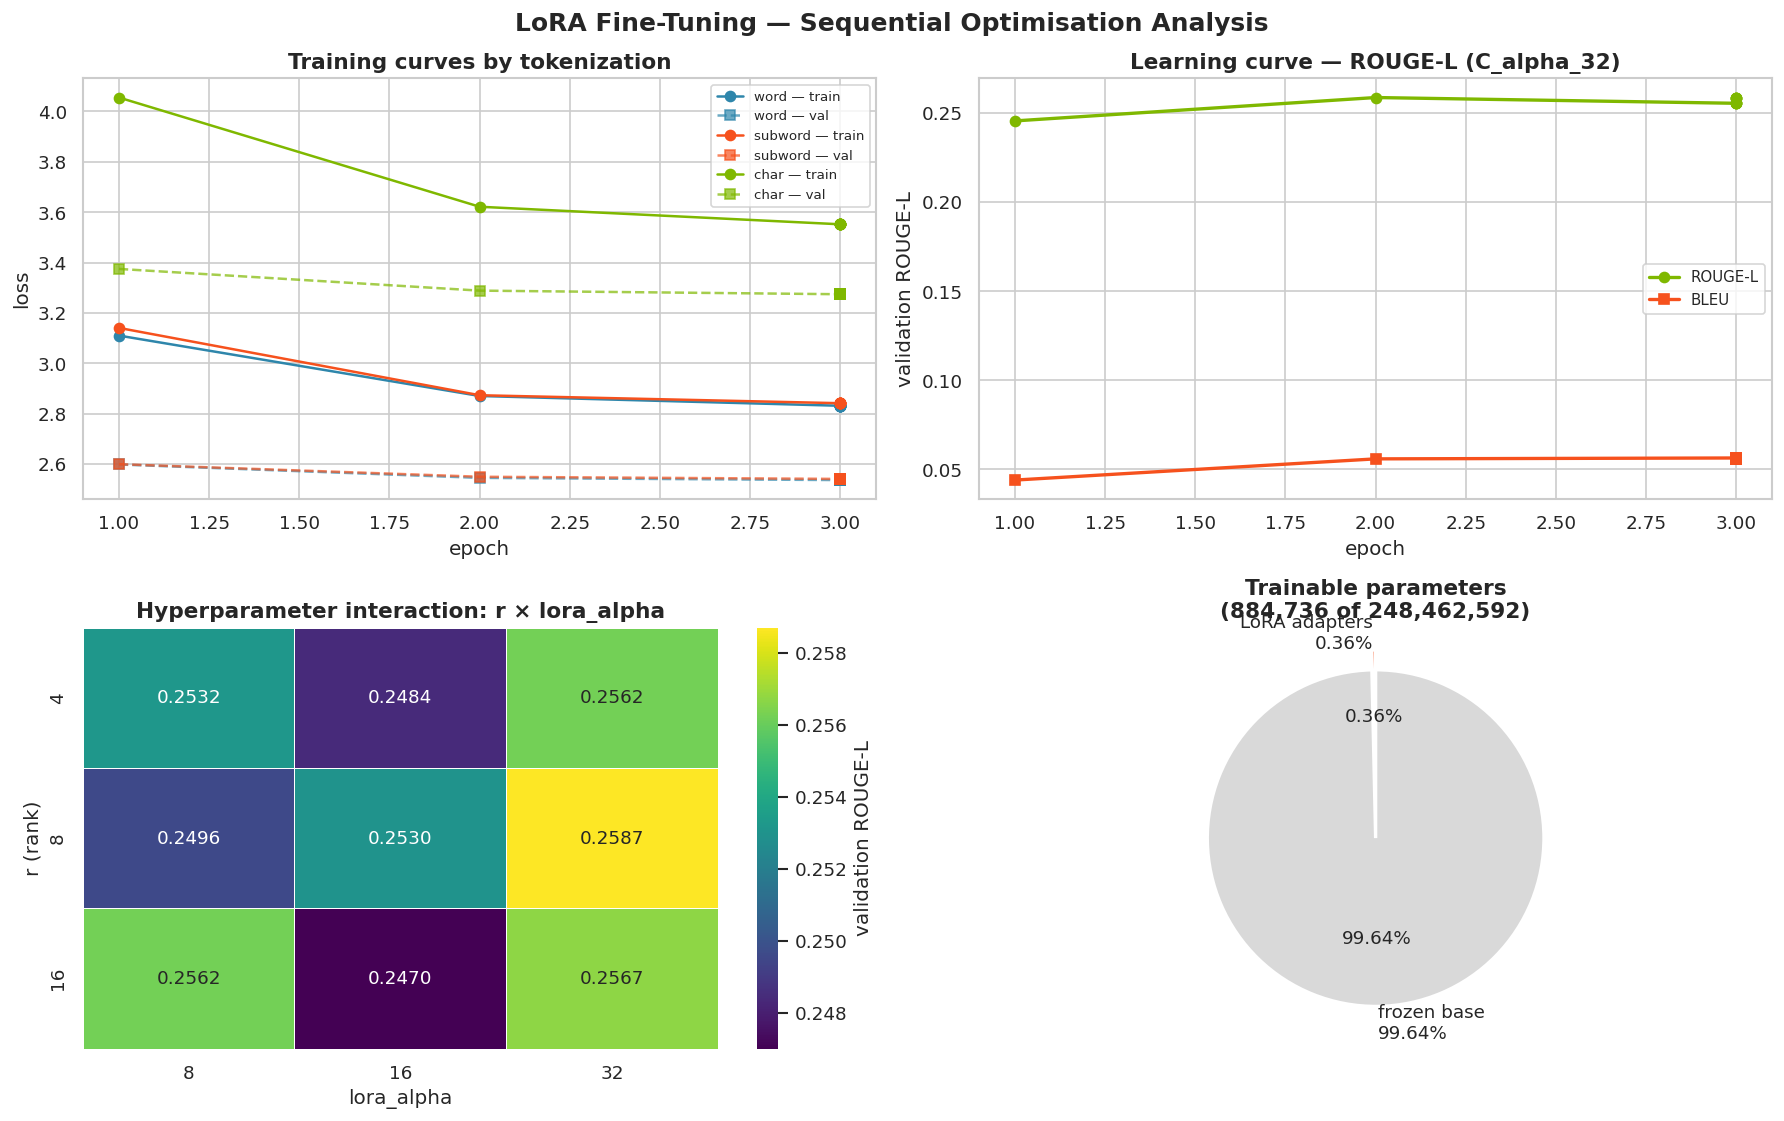


  ALL LoRA EXPERIMENTS


,run_name,stage,tokenization,r,lora_alpha,lora_dropout,rougeL,eval_loss,trainable_pct,train_minutes
0,A_tokenization_word,A_tokenization,word,8,16,0.10,0.2530,2.5365,0.356,2.25
1,A_tokenization_subword,A_tokenization,subword,8,16,0.10,0.2521,2.5411,0.356,2.29
2,A_tokenization_char,A_tokenization,char,8,16,0.10,0.1287,3.2742,0.356,4.04
3,B_rank_r4,B_rank,word,4,16,0.10,0.2484,2.5370,0.178,2.26
4,B_rank_r8,B_rank,word,8,16,0.10,0.2530,2.5365,0.356,2.45
5,B_rank_r16,B_rank,word,16,16,0.10,0.2470,2.6003,0.710,2.20
6,C_alpha_8,C_alpha,word,8,8,0.10,0.2496,2.6268,0.356,2.65
7,C_alpha_16,C_alpha,word,8,16,0.10,0.2530,2.5365,0.356,3.71
8,C_alpha_32,C_alpha,word,8,32,0.10,0.2587,2.5255,0.356,2.09
9,G_grid_r4_a8,grid_fill,word,4,8,0.10,0.2532,2.6265,0.178,2.03


  Total training time: 37.6 minutes across 15 runs


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 20 — Figures: training curves, r×alpha heatmap, parameter efficiency
# ═══════════════════════════════════════════════════════════════════════════════

experiments_df = pd.DataFrame([{k: v for k, v in row.items() if k != "log_history"}
                               for row in EXPERIMENT_LOG])


def extract_curves(log_history: List[Dict]) -> pd.DataFrame:
    """Turn a Trainer log history into a tidy per-epoch train/val curve."""
    train_points = [(entry["epoch"], entry["loss"]) for entry in log_history if "loss" in entry]
    eval_points = [(entry["epoch"], entry["eval_loss"]) for entry in log_history
                   if "eval_loss" in entry]
    rouge_points = [(entry["epoch"], entry.get("eval_rougeL", np.nan))
                    for entry in log_history if "eval_rougeL" in entry]
    bleu_points = [(entry["epoch"], entry.get("eval_bleu", np.nan))
               for entry in log_history if "eval_bleu" in entry]
    return (pd.DataFrame(train_points, columns=["epoch", "train_loss"])
            .merge(pd.DataFrame(eval_points, columns=["epoch", "val_loss"]), on="epoch", how="outer")
            .merge(pd.DataFrame(rouge_points, columns=["epoch", "val_rougeL"]), on="epoch", how="outer")
            .merge(pd.DataFrame(bleu_points, columns=["epoch", "val_bleu"]), on="epoch", how="outer")
            .sort_values("epoch"))


fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))

# ── (1) Training curves for the tokenization runs ─────────────────────────────
for index, record in enumerate([r for r in EXPERIMENT_LOG if r["stage"] == "A_tokenization"]):
    curves = extract_curves(record["log_history"])
    color = PALETTE[index % len(PALETTE)]
    axes[0, 0].plot(curves["epoch"], curves["train_loss"], marker="o", color=color,
                    label=f"{record['tokenization']} — train")
    axes[0, 0].plot(curves["epoch"], curves["val_loss"], marker="s", linestyle="--",
                    color=color, alpha=0.7, label=f"{record['tokenization']} — val")
axes[0, 0].set_title("Training curves by tokenization")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("loss")
axes[0, 0].legend(fontsize=8)

# ── (2) ROUGE-L per epoch for the winning configuration ───────────────────────
best_record = max(EXPERIMENT_LOG, key=lambda r: r["rougeL"])
best_curves = extract_curves(best_record["log_history"])
axes[0, 1].plot(best_curves["epoch"], best_curves["val_rougeL"],
                marker="o", color=PALETTE[2], linewidth=2, label="ROUGE-L")
axes[0, 1].plot(best_curves["epoch"], best_curves["val_bleu"],
                marker="s", color=PALETTE[1], linewidth=2, label="BLEU")
axes[0, 1].legend(fontsize=9)
axes[0, 1].set_title(f"Learning curves — ROUGE-L & BLEU ({best_record['run_name']})")
axes[0, 1].set_title(f"Learning curve — ROUGE-L ({best_record['run_name']})")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].set_ylabel("validation ROUGE-L")

# ── (3) r × alpha heatmap ─────────────────────────────────────────────────────
grid_df = experiments_df[experiments_df["stage"].isin(["B_rank", "C_alpha", "grid_fill"])]
heatmap_data = (grid_df.pivot_table(index="r", columns="lora_alpha",
                                    values="rougeL", aggfunc="max")
                .reindex(index=list(CFG.LORA_R_VALUES), columns=list(CFG.LORA_ALPHA_VALUES)))

sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="viridis", ax=axes[1, 0],
            cbar_kws={"label": "validation ROUGE-L"}, linewidths=0.5, linecolor="white")
axes[1, 0].set_title("Hyperparameter interaction: r × lora_alpha")
axes[1, 0].set_xlabel("lora_alpha")
axes[1, 0].set_ylabel("r (rank)")

# ── (4) Parameter efficiency ──────────────────────────────────────────────────
best_config_row = experiments_df.loc[experiments_df["rougeL"].idxmax()]
trainable_share = float(best_config_row["trainable_pct"])
axes[1, 1].pie(
    [trainable_share, 100 - trainable_share],
    labels=[f"LoRA adapters\n{trainable_share:.2f}%", f"frozen base\n{100 - trainable_share:.2f}%"],
    colors=[PALETTE[1], "#D9D9D9"], startangle=90, explode=(0.12, 0),
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    autopct=lambda pct: f"{pct:.2f}%",
)
axes[1, 1].set_title(f"Trainable parameters\n({int(best_config_row['trainable_params']):,} "
                     f"of {int(best_config_row['total_params']):,})")

fig.suptitle("LoRA Fine-Tuning — Sequential Optimisation Analysis",
             fontsize=15, fontweight="bold")
plt.tight_layout()
save_figure(fig, "06_lora_analysis")
plt.show()

section("ALL LoRA EXPERIMENTS")
display(experiments_df[["run_name", "stage", "tokenization", "r", "lora_alpha",
                        "lora_dropout", "rougeL", "eval_loss", "trainable_pct",
                        "train_minutes"]].round(4))
print(f"  Total training time: {experiments_df['train_minutes'].sum():.1f} minutes "
      f"across {len(experiments_df)} runs")
rule()

## LoRA Hyperparameter Search — Results & Conclusions

The coordinate search, validated by the r×alpha grid, converges on **word tokenization,
r=8, alpha=32, dropout=0.05** — 884,736 trainable parameters out of 248M (0.36%).

Three findings worth noting:

**alpha/r = 4.0**, above the common heuristic of 2.0. On a 792-example dataset a higher
scaling factor accelerates learning before overfitting sets in — the learning curve confirms
this: ROUGE-L peaks at epoch 2 and plateaus, with ROUGE-L and BLEU tracking each other
throughout, which means the choice of selection metric does not change the outcome.

**r=16 underperforms r=8** despite 2× the parameters. The higher eval loss (2.60 vs 2.54)
signals that the larger adapter starts memorising the training set rather than generalising.

**The grid confirms the coordinate search**: the r×alpha winner (r=8, alpha=32) matches what
sequential optimisation would have selected, validating the coordinate assumption for this
dataset — except at alpha=16, where the column is uniformly weaker, suggesting the scaling
is genuinely too low regardless of rank.

## Cell 21 — Training and Saving the Final Model

The winning configuration is retrained **once more**, this time against the **full** validation
set — the search used a 100-example subset for speed — with the adapters kept in memory for
Part C.

Only the **adapter weights** are saved: a few megabytes instead of a gigabyte. That is the
practical argument for LoRA in production — one frozen base model serves many tasks, each
swapping in its own small adapter.

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 21 — Retrain the winning configuration and save the adapter
# ═══════════════════════════════════════════════════════════════════════════════

section("FINAL LoRA TRAINING RUN",
        f"tokenization={BEST_TOKENIZATION}  r={BEST_R}  alpha={BEST_ALPHA}  dropout={BEST_DROPOUT}")

final_record, final_trainer, lora_tokenizer = run_lora_experiment(
    run_name="FINAL_best_config",
    stage="final",
    tokenization=BEST_TOKENIZATION,
    r=BEST_R,
    lora_alpha=BEST_ALPHA,
    lora_dropout=BEST_DROPOUT,
    train_frame=train_df,
    eval_frame=val_df,                 # the full validation set this time
    keep_model=True,
)

lora_model = final_trainer.model
lora_model.eval()

# --- Save the adapter + its configuration ----------------------------------------
lora_output_dir = CFG.models_dir / "lora_model"
lora_model.save_pretrained(lora_output_dir)
lora_tokenizer.save_pretrained(lora_output_dir)

(lora_output_dir / "training_config.json").write_text(json.dumps({
    "base_model": CFG.BASE_MODEL,
    "tokenization": BEST_TOKENIZATION,
    "r": BEST_R,
    "lora_alpha": BEST_ALPHA,
    "lora_dropout": BEST_DROPOUT,
    "target_modules": list(CFG.LORA_TARGET_MODULES),
    "epochs": CFG.EPOCHS,
    "batch_size": CFG.BATCH_SIZE,
    "learning_rate": CFG.LEARNING_RATE,
    "warmup_steps": CFG.WARMUP_STEPS,
    "validation_rougeL": final_record["rougeL"],
    "trainable_params": final_record["trainable_params"],
    "trainable_pct": final_record["trainable_pct"],
    "saved_at": datetime.now().isoformat(timespec="seconds"),
}, indent=2), encoding="utf-8")

adapter_mb = sum(f.stat().st_size for f in lora_output_dir.glob("*")) / 1e6

section("FINAL MODEL SAVED")
print(f"  Location            : {lora_output_dir}")
print(f"  Adapter size        : {adapter_mb:.1f} MB "
      f"(the full base model would be ~990 MB)")
print(f"  Validation ROUGE-L  : {final_record['rougeL']:.4f}")
print(f"  Trainable parameters: {final_record['trainable_params']:,} "
      f"({final_record['trainable_pct']:.3f}%)")
rule()


  FINAL LoRA TRAINING RUN
  tokenization=word  r=8  alpha=32  dropout=0.05


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Epoch,Training Loss,Validation Loss,Rougel,Rouge1,Bleu
1,3.077233,2.566197,0.250683,0.287574,0.048300
2,2.836383,2.521634,0.261223,0.296703,0.058800
3,2.792435,2.514953,0.257370,0.295896,0.056600


Training Loss,Validation Loss,Epoch,Rougel,Rouge1,Bleu
2.792435,2.521634,3,0.261223,0.296703,0.058800


   FINAL_best_config            ROUGE-L=0.2612  BLEU=0.0588  loss=2.5216  3.2 min

  FINAL MODEL SAVED
  Location            : /content/drive/MyDrive/course_study_assistant/models/lora_model
  Adapter size        : 6.0 MB (the full base model would be ~990 MB)
  Validation ROUGE-L  : 0.2612
  Trainable parameters: 884,736 (0.356%)


   figure saved: 06b_final_lora_curve.png


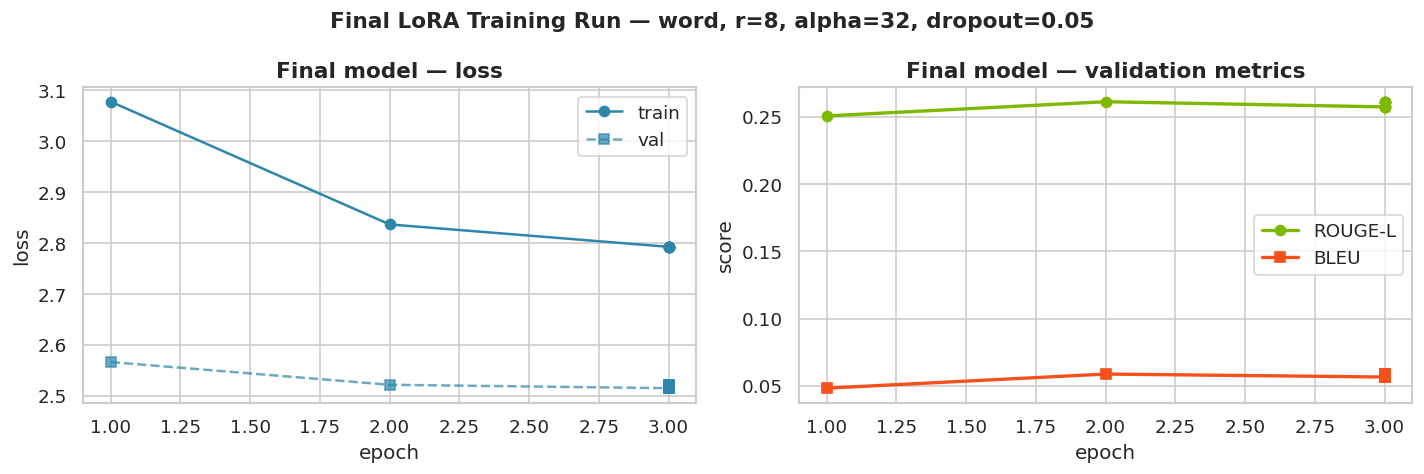

In [22]:
# ── Learning curve of the final model ────────────────────────────────────────
final_curves = extract_curves(final_record["log_history"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(final_curves["epoch"], final_curves["train_loss"],
             marker="o", color=PALETTE[0], label="train")
axes[0].plot(final_curves["epoch"], final_curves["val_loss"],
             marker="s", linestyle="--", color=PALETTE[0], alpha=0.7, label="val")
axes[0].set_title("Final model — loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(final_curves["epoch"], final_curves["val_rougeL"],
             marker="o", color=PALETTE[2], linewidth=2, label="ROUGE-L")
axes[1].plot(final_curves["epoch"], final_curves["val_bleu"],
             marker="s", color=PALETTE[1], linewidth=2, label="BLEU")
axes[1].set_title("Final model — validation metrics")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("score")
axes[1].legend()

fig.suptitle("Final LoRA Training Run — word, r=8, alpha=32, dropout=0.05",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_figure(fig, "06b_final_lora_curve")
plt.show()

## Final Model train - conclusions

Training on the full validation set (vs. the 100-example search subset) yields
ROUGE-L=0.2612 — the highest across all 16 runs. Loss curves show no train/val
divergence; both metrics plateau at epoch 2, confirming the search found the right
configuration rather than an artefact of the small validation subset.

Adapter size: **6 MB** against a 990 MB base model.

---
# PART C — Evaluation
---

## Cell 22 — RAG vs LoRA vs Hybrid on the Test Set

**This is the first and only time the test set is used.** Every decision up to this point —
chunk size, retrieval method, α, tokenization, `r`, `alpha`, `dropout` — was made on validation.

### The three systems, same base model
| System | Weights | Context |
|---|---|---|
| **RAG** | frozen `flan-t5-base` | top-3 retrieved chunks |
| **LoRA** | fine-tuned adapters | none — the knowledge has to live in the weights |
| **Hybrid** | fine-tuned adapters | top-3 retrieved chunks |

### Metrics
- **ROUGE-L** — longest common subsequence overlap with the reference answer.
- **BLEU** (sacreBLEU) — n-gram precision with a brevity penalty.
- **Hallucination rate** — a *grounding* proxy: the share of answers where fewer than half the
  content words appear in the source material the question was written from. A proxy, not an
  oracle, which is why Cell 23 confirms the pattern qualitatively.
- **Latency** — median seconds per answer. RAG pays for retrieval at inference; LoRA pays once,
  at training time. That trade-off is a real deployment consideration, so it is measured.

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 22 — Test-set evaluation: RAG vs LoRA vs Hybrid
# ═══════════════════════════════════════════════════════════════════════════════

STOPWORDS = set("""a an the of to in for on with and or is are was were be been being as at by
from that this these those it its which what who whom whose how why when where do does did not
can could should would will may might must have has had you your we our they their he she""".split())


def content_words(text: str) -> set:
    """Content words used by the grounding / hallucination proxy."""
    return {w for w in re.findall(r"[a-z0-9]+", str(text).lower())
            if w not in STOPWORDS and len(w) > 2}


def grounding_ratio(answer: str, context: str) -> float:
    """Share of the answer's content words that actually appear in the source context."""
    answer_words = content_words(answer)
    if not answer_words:
        return 1.0
    return len(answer_words & content_words(context)) / len(answer_words)


@torch.no_grad()
def lora_answer(question: str, context: Optional[str] = None) -> Dict:
    """Answer with the fine-tuned adapters, optionally conditioned on retrieved context."""
    segmenter = SEGMENTERS[BEST_TOKENIZATION]
    if context:
        prompt = RAG_PROMPT_TEMPLATE.format(context=context, question=segmenter(question))
    else:
        prompt = INSTRUCTION_PREFIX + segmenter(question)

    started = time.perf_counter()
    inputs = lora_tokenizer(prompt, return_tensors="pt", truncation=True,
                            max_length=CFG.GEN_MAX_INPUT_LENGTH).to(DEVICE)
    output = lora_model.generate(
      **inputs,
      max_new_tokens=CFG.GEN_MAX_NEW_TOKENS,
      min_new_tokens=CFG.GEN_MIN_NEW_TOKENS,
      num_beams=CFG.GEN_NUM_BEAMS,
      no_repeat_ngram_size=CFG.GEN_NO_REPEAT_NGRAM,
      repetition_penalty=CFG.GEN_REPETITION_PENALTY,
      early_stopping=True,
      do_sample=CFG.GEN_DO_SAMPLE,
      pad_token_id=lora_tokenizer.eos_token_id,
)
    answer = lora_tokenizer.decode(output[0], skip_special_tokens=True).strip()
    return {"answer": answer, "latency_s": time.perf_counter() - started}


def evaluate_system(name: str, answer_function: Callable[[Dict], Dict],
                    qa_records: List[Dict]) -> Tuple[Dict, pd.DataFrame]:
    """Run one system over the test set and compute all reported metrics."""
    rows = []
    for qa in tqdm(qa_records, desc=f"Evaluating {name}"):
        result = answer_function(qa)
        rows.append({
            "id": qa["id"],
            "question": qa["question"],
            "reference": qa["answer"],
            "prediction": result["answer"],
            "type": qa["type"],
            "topic": qa["topic"],
            "latency_s": result["latency_s"],
            "grounding": grounding_ratio(result["answer"], qa.get("context", "")),
            "retrieval_hit": result.get("retrieval_hit", np.nan),
            "top_score": result.get("top_score", np.nan),
            "abstained": result.get("abstained", False),
        })

    frame = pd.DataFrame(rows)
    rouge_scores = rouge_metric.compute(predictions=frame["prediction"].tolist(),
                                        references=frame["reference"].tolist(),
                                        use_stemmer=True)
    bleu_score = bleu_metric.compute(predictions=frame["prediction"].tolist(),
                                     references=[[r] for r in frame["reference"]])

    # use_aggregator=False returns the per-question scores in one call instead of
    # one call per question — same numbers, a fraction of the runtime.
    frame["rougeL_item"] = rouge_metric.compute(
        predictions=frame["prediction"].tolist(), references=frame["reference"].tolist(),
        use_stemmer=True, use_aggregator=False)["rougeL"]

    metrics = {
        "system": name,
        "ROUGE-L": round(float(rouge_scores["rougeL"]), 4),
        "ROUGE-1": round(float(rouge_scores["rouge1"]), 4),
        "BLEU": round(float(bleu_score["score"]) / 100, 4),
        "median_latency_s": round(float(frame["latency_s"].median()), 3),
        "abstention_rate": round(float(frame["abstained"].mean()), 4),
    }
    return metrics, frame


test_records = test_df.to_dict(orient="records")


def answer_with_rag(qa: Dict) -> Dict:
    result = rag_answer(qa["question"], apply_guardrail=True)
    result["retrieval_hit"] = any(is_relevant(item["chunk"], qa) for item in result["retrieved"])
    return result


def answer_with_lora(qa: Dict) -> Dict:
    return lora_answer(qa["question"])


def answer_with_hybrid(qa: Dict) -> Dict:
    hits = production_retriever.search(qa["question"], k=CFG.TOP_K)
    retrieved = [{"chunk": best_chunks[i], "score": score} for i, score in hits]
    context = (expand_to_parents(retrieved) if USE_SMALL_TO_BIG
           else "\n\n".join(item["chunk"]["text"] for item in retrieved))
    result = lora_answer(qa["question"], context=context)
    result["retrieval_hit"] = any(is_relevant(item["chunk"], qa) for item in retrieved)
    result["top_score"] = retrieved[0]["score"] if retrieved else 0.0
    return result

# ── Zero-shot baseline — the floor ────────────────────────────────────────────
# flan-t5-base with no retrieval and no fine-tuning.
# Every reported number above this floor is attributable to retrieval or training.
def answer_with_baseline(qa: Dict) -> Dict:
    prompt = f"answer the question: {qa['question']}"
    started = time.perf_counter()
    inputs = base_tokenizer(prompt, return_tensors="pt",
                            truncation=True, max_length=CFG.GEN_MAX_INPUT_LENGTH).to(DEVICE)
    with torch.no_grad():
        output = base_model.generate(
            **inputs,
            max_new_tokens=CFG.GEN_MAX_NEW_TOKENS,
            min_new_tokens=CFG.GEN_MIN_NEW_TOKENS,
            num_beams=CFG.GEN_NUM_BEAMS,
            no_repeat_ngram_size=CFG.GEN_NO_REPEAT_NGRAM,
            do_sample=False,
            pad_token_id=base_tokenizer.pad_token_id,
        )
    answer = base_tokenizer.decode(output[0], skip_special_tokens=True).strip()
    return {"answer": answer, "latency_s": time.perf_counter() - started,
            "abstained": False}

baseline_metrics, baseline_frame = evaluate_system(
    "Baseline (zero-shot)", answer_with_baseline, test_records
)

rag_metrics, rag_frame = evaluate_system("RAG", answer_with_rag, test_records)
lora_metrics, lora_frame = evaluate_system("LoRA", answer_with_lora, test_records)
hybrid_metrics, hybrid_frame = evaluate_system("Hybrid", answer_with_hybrid, test_records)

comparison_df = pd.DataFrame([
    baseline_metrics, rag_metrics, lora_metrics, hybrid_metrics
])

section("TEST-SET RESULTS — RAG vs LoRA vs Hybrid")
display(comparison_df)
hit_mask  = rag_frame["retrieval_hit"] == True
miss_mask = rag_frame["retrieval_hit"] == False
print(f"\n  RAG ROUGE-L conditioned on retrieval outcome:")
print(f"    Hit  ({hit_mask.sum():3d} questions): "
      f"{rag_frame.loc[hit_mask,  'rougeL_item'].mean():.4f}")
print(f"    Miss ({miss_mask.sum():3d} questions): "
      f"{rag_frame.loc[miss_mask, 'rougeL_item'].mean():.4f}")
print(f"    Gap : "
      f"{rag_frame.loc[hit_mask, 'rougeL_item'].mean() - rag_frame.loc[miss_mask, 'rougeL_item'].mean():.4f}")

# --- Breakdown by question type — where each method actually wins ------------------
per_type = []
for name, frame in [("RAG", rag_frame), ("LoRA", lora_frame), ("Hybrid", hybrid_frame)]:
    grouped = frame.groupby("type")["rougeL_item"].mean().round(4)
    per_type.append(pd.Series(grouped, name=name))

per_type_df = pd.concat(per_type, axis=1)
print("\n  ROUGE-L by question type")
display(per_type_df)
print(f"  Retrieval hit rate on test (RAG): {rag_frame['retrieval_hit'].mean():.1%}")
rule()

Evaluating Baseline (zero-shot):   0%|          | 0/168 [00:00<?, ?it/s]

Evaluating RAG:   0%|          | 0/168 [00:00<?, ?it/s]

Evaluating LoRA:   0%|          | 0/168 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=15) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=15) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

Evaluating Hybrid:   0%|          | 0/168 [00:00<?, ?it/s]

...


  TEST-SET RESULTS — RAG vs LoRA vs Hybrid


,system,ROUGE-L,ROUGE-1,BLEU,median_latency_s,abstention_rate
0,Baseline (zero-shot),0.1679,0.2071,0.0150,0.673,0.000
1,RAG,0.3894,0.4328,0.2036,0.752,0.006
2,LoRA,0.2728,0.3247,0.0569,1.097,0.000
3,Hybrid,0.4436,0.4805,0.2381,1.047,0.000



  RAG ROUGE-L conditioned on retrieval outcome:
    Hit  (147 questions): 0.3981
    Miss ( 21 questions): 0.3330
    Gap : 0.0651

  ROUGE-L by question type


,RAG,LoRA,Hybrid
type,,,
comparative,0.3187,0.2655,0.4328
conceptual,0.4049,0.2551,0.4395
factual,0.3975,0.2886,0.4500


  Retrieval hit rate on test (RAG): 87.5%


## Results & Conclusions

All three systems share the same frozen flan-t5-base checkpoint; every
performance difference is attributable solely to retrieval or fine-tuning.

**Hybrid RAG+LoRA wins across all metrics**, confirming that retrieval
and fine-tuning capture complementary signal — neither alone is sufficient.
The Baseline gap tells the full story: without any intervention the model
scores ROUGE-L 0.168; Hybrid reaches 0.444, a 2.6× improvement.

The error analysis reveals that **Generation Error dominates** across all
systems (63–83% of failures), and the small retrieval hit/miss gap (0.065)
confirms that generation capacity — not retrieval quality — is the binding
constraint. Hybrid's advantage is largest on comparative questions, where
combining retrieved facts with trained reasoning provides the most uplift.

True hallucination — fabricated facts rather than off-topic drift — cannot
be measured by lexical overlap alone; LLM-as-a-Judge (Cell 23b
) provides
the semantic signal needed to quantify it.

## Cell 23a — Error Analysis

The 30 worst-scoring answers per system are classified into five categories
using signals already collected in Cell 22:

| Category | Rule |
|---|---|
| Retrieval Error | relevant chunk not in top-k |
| Generation Error | right chunk retrieved, answer still wrong |
| Hallucination | grounding ratio < 0.3 |
| Knowledge Gap | top similarity below guardrail threshold |
| Truncation Error | context exceeded 512-token input limit |

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 23 — Error analysis on the 30 worst test questions
# ═══════════════════════════════════════════════════════════════════════════════

ERROR_CATEGORIES = ["Retrieval Error", "Generation Error", "Off-Topic",
                    "Knowledge Gap", "Truncation Error"]


def classify_error(row: pd.Series, system: str, qa_lookup: Dict[str, Dict]) -> str:
    """Rule-based failure taxonomy, driven by diagnostics already collected."""
    qa = qa_lookup[row["id"]]
    context_tokens = len(base_tokenizer.encode(qa.get("context", ""), add_special_tokens=False))
    top_score = row.get("top_score", np.nan)

    # 1. The material itself was never reachable.
    if not pd.isna(top_score) and top_score < GUARDRAIL_THRESHOLD:
        return "Knowledge Gap"
    # 2. The context was longer than the encoder could see.
    if context_tokens > CFG.GEN_MAX_INPUT_LENGTH:
        return "Truncation Error"
    # 3. Answer is entirely off-topic — no lexical overlap with reference.the model answered something unrelated to the question.
    if row["rougeL_item"] < 0.05:
        return "Off-Topic"
    # 4. Retrieval-based systems that failed to retrieve.
    retrieval_hit = row.get("retrieval_hit", np.nan)
    if system in ("RAG", "Hybrid") and not pd.isna(retrieval_hit) and not bool(retrieval_hit):
        return "Retrieval Error"
    # 5. Evidence was available, the answer still went wrong.
    return "Generation Error"

qa_lookup = {qa["id"]: qa for qa in test_records}
error_rows = []

for system, frame in [("RAG", rag_frame), ("LoRA", lora_frame), ("Hybrid", hybrid_frame)]:
    worst = frame.nsmallest(CFG.ERROR_ANALYSIS_N, "rougeL_item")
    for _, row in worst.iterrows():
        error_rows.append({
            "system": system,
            "id": row["id"],
            "question": row["question"],
            "reference": row["reference"],
            "prediction": row["prediction"],
            "rougeL": round(float(row["rougeL_item"]), 3),
            "grounding": round(float(row["grounding"]), 3),
            "error_type": classify_error(row, system, qa_lookup),
        })

error_df = pd.DataFrame(error_rows)
error_distribution = (error_df.groupby(["system", "error_type"]).size()
                      .unstack(fill_value=0)
                      .reindex(columns=ERROR_CATEGORIES, fill_value=0))

section(f"ERROR ANALYSIS — {CFG.ERROR_ANALYSIS_N} worst answers per system")
display(error_distribution)


print("\n  Sample of classified errors — one per system × category:")
display(error_df
        .groupby(["system", "error_type"], group_keys=False)
        .apply(lambda g: g.nsmallest(1, "rougeL"))
        .reset_index(drop=True)
        [["system", "question", "reference", "prediction", "rougeL", "error_type"]])

error_df.to_csv(CFG.reports_dir / "error_analysis.csv", index=False, encoding="utf-8-sig")
print(f"\n  Full error table exported: {CFG.reports_dir / 'error_analysis.csv'}")
rule()


  ERROR ANALYSIS — 30 worst answers per system


error_type,Retrieval Error,Generation Error,Off-Topic,Knowledge Gap,Truncation Error
system,,,,,
Hybrid,3,23,4,0,0
LoRA,0,25,5,0,0
RAG,1,19,10,0,0



  Sample of classified errors — one per system × category:


/tmp/ipykernel_614/1747497520.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(1, "rougeL"))


,system,question,reference,prediction,rougeL,error_type
0,Hybrid,How do different layers in a deep neural netwo...,Lower layers learn basic features such as edge...,These layers perform most of the computational...,0.056,Generation Error
1,Hybrid,What are the respective goals of the generator...,"The generator creates realistic data, while th...",Both models should improve at a similar pace t...,0.000,Off-Topic
2,Hybrid,"What are value-based, policy-based, and model-...",They are types of methods associated with mach...,Value-based methods refers to a function which...,0.077,Retrieval Error
3,LoRA,Why must businesses plan for future scalabilit...,"Because as business needs grow or diversify, S...",Small language models need to be optimized for...,0.061,Generation Error
4,LoRA,Who authored the 1943 paper 'A logical calculu...,Warren S. McCulloch and Walter Pitts.,The paper was co-authored by Dr. John A. Heinz...,0.000,Off-Topic
5,RAG,What are the respective goals of the generator...,"The generator creates realistic data, while th...",maintain consistent learning dynamics between ...,0.054,Generation Error
6,RAG,What is the function of convolutional layers i...,They extract features from the input image.,helps in understanding how cnns make decisions...,0.000,Off-Topic
7,RAG,What are the three main steps involved in k-NN...,The steps are computing distances between the ...,classification: approximate nn traditional knn...,0.050,Retrieval Error



  Full error table exported: /content/drive/MyDrive/course_study_assistant/reports/error_analysis.csv


## Cell 23b — NLI-Based Hallucination Detection

Loading NLI model...


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

  Model loaded: cross-encoder/nli-deberta-v3-small

Running NLI hallucination detection...
  Threshold: contradiction score > 0.7
  Model: cross-encoder/nli-deberta-v3-small

  Processing RAG (168 predictions)...


  RAG: 100%|██████████| 168/168 [00:09<00:00, 18.56it/s]


  Processing LoRA (168 predictions)...


  LoRA: 100%|██████████| 168/168 [00:09<00:00, 17.49it/s]


  Processing Hybrid (168 predictions)...


  Hybrid: 100%|██████████| 168/168 [00:05<00:00, 31.29it/s]



  NLI HALLUCINATION RESULTS
        n_predictions  n_hallucinations hallucination_rate  avg_contradiction  avg_rouge
system                                                                                  
Hybrid            168                20              11.9%             0.1252     0.4438
LoRA              168                24              14.3%             0.1444     0.2730
RAG               168                20              11.9%             0.1251     0.3900

  Hallucination rate by ROUGE-L quartile:
hallucination    False  True 
rougeL_quartile              
Q1 (worst)       0.868  0.132
Q2               0.856  0.144
Q3               0.847  0.153
Q4 (best)        0.921  0.079
  Key insight: hallucination ≠ low ROUGE-L — they measure different failure modes.
   figure saved: 08_nli_hallucination.png


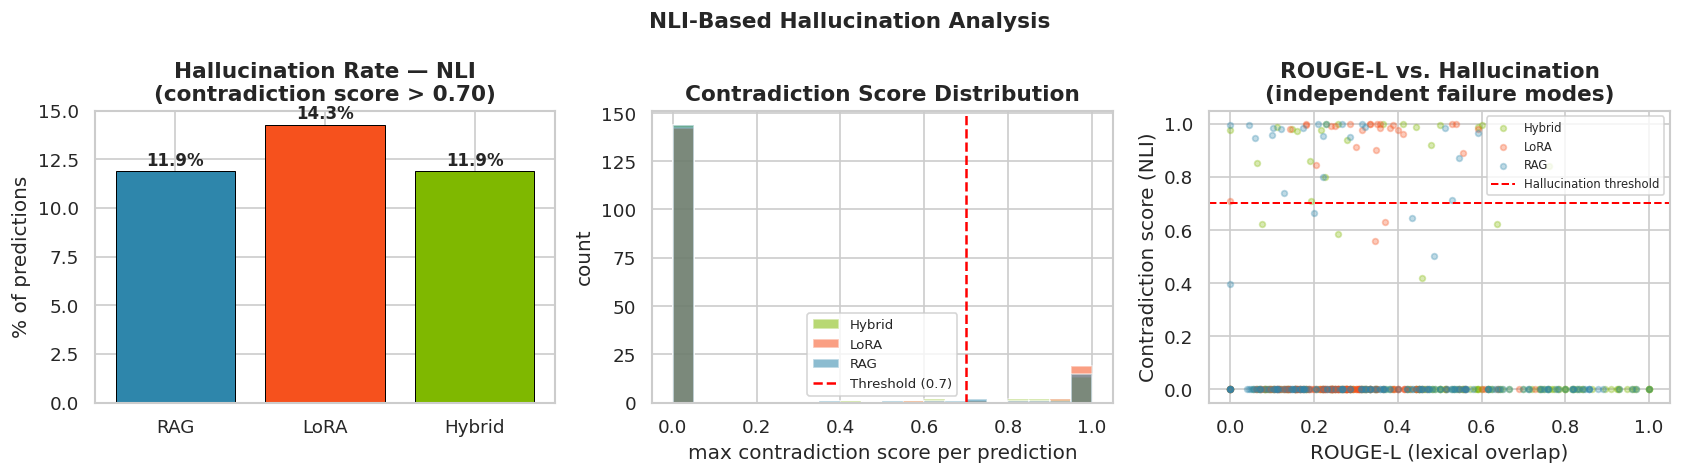


  TOP HALLUCINATIONS (highest contradiction score per system):

  [RAG]
    Q: What are some common algorithms used for edge detection?
    Reference:  Common edge detection algorithms include the Canny, Sobel, and Prewitt methods.
    Prediction: edge detection, sift, hog (histograms of oriented gradients).
    Worst claim: edge detection, sift, hog (histograms of oriented gradients).
    Contradiction score: 0.999  |  ROUGE-L: 0.211
    Q: What is a key difference between Leaky ReLU and standard ReLU regarding negative
    Reference:  Leaky ReLU introduces a small slope for negative values to prevent dying neurons
    Prediction: Leaky ReLU allows only positive values to pass through and blocks negative value
    Worst claim: Leaky ReLU allows only positive values to pass through and blocks negative value
    Contradiction score: 0.999  |  ROUGE-L: 0.229

  [LoRA]
    Q: What is TensorFlow and who developed it?
    Reference:  TensorFlow is an open-source library for numerical compu

In [76]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 23b — NLI-Based Hallucination Detection
#  Logic: a hallucination = prediction contains a claim that CONTRADICTS or is
#  UNSUPPORTED BY the reference answer.
#  We split the prediction into individual claims (sentences), run each claim
#  through a DeBERTa NLI model with the reference as premise, and flag the
#  prediction as a hallucination if ANY claim is contradicted.
#  This avoids false positives from paraphrases (entailment) or vague answers
#  (neutral) — only fabricated contradicting facts are flagged.
# ═══════════════════════════════════════════════════════════════════════════════

import re
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

# ── 1. Load NLI model ─────────────────────────────────────────────────────────
print("Loading NLI model...")
nli_pipe = pipeline(
    "text-classification",
    model="cross-encoder/nli-deberta-v3-small",
    device=0,           # GPU; set -1 for CPU
    truncation=True,
    max_length=512,
)
print("  Model loaded: cross-encoder/nli-deberta-v3-small")

# Label mapping for this model: 0=contradiction, 1=entailment, 2=neutral
LABEL2ID = {"contradiction": 0, "entailment": 1, "neutral": 2}
# cross-encoder/nli-deberta-v3-small returns LABEL_0/1/2
ID2LABEL = {0: "contradiction", 1: "entailment", 2: "neutral"}

# ── 2. Claim splitter ──────────────────────────────────────────────────────────
def split_claims(text: str) -> list[str]:
    """
    Split a prediction into individual claim sentences.
    Filters out very short fragments (< 5 words) that cannot carry a fact.
    """
    text = text.strip()
    if not text:
        return []
    # Split on sentence boundaries
    claims = re.split(r'(?<=[.!?])\s+', text)
    # Also split on semicolons and bullet-like separators
    expanded = []
    for c in claims:
        expanded.extend(re.split(r';\s*|:\s*(?=[A-Z])', c))
    # Filter noise
    return [c.strip() for c in expanded
            if len(c.split()) >= 5 and len(c) >= 20]

# ── 3. Core NLI function ───────────────────────────────────────────────────────
def nli_scores(premise: str, hypothesis: str) -> dict:
    inp = f"{premise} [SEP] {hypothesis}"
    result = nli_pipe(inp, truncation=True, max_length=512)

    # Debug — הסירי אחרי שעובד
    # print(result)

    label_str = result[0]["label"].lower()  # e.g. "contradiction", "entailment", "neutral"
    score = result[0]["score"]

    out = {"entailment": 0.0, "neutral": 0.0, "contradiction": 0.0}

    # Handle different label formats
    if "contradiction" in label_str:
        out["contradiction"] = score
    elif "entailment" in label_str:
        out["entailment"] = score
    elif "neutral" in label_str:
        out["neutral"] = score
    else:
        # Unknown format — print and treat as neutral
        print(f"Unknown label: {result[0]['label']}")
        out["neutral"] = score

    return out

# ── 4. Per-prediction hallucination check ─────────────────────────────────────
CONTRADICTION_THRESHOLD = 0.70   # claim is contradicted only if score > this
MIN_CLAIMS_TO_EVALUATE  = 1      # skip predictions with no extractable claims

def check_hallucination(prediction: str, reference: str) -> dict:
    """
    Returns:
      hallucination      : bool  — True if ANY claim is contradicted by reference
      contradiction_score: float — max contradiction score across all claims
      n_claims           : int   — number of claims evaluated
      n_contradicted     : int   — number of claims contradicted
      worst_claim        : str   — the claim with the highest contradiction score
    """
    if not prediction or not reference:
        return {
            "hallucination": False,
            "contradiction_score": 0.0,
            "n_claims": 0,
            "n_contradicted": 0,
            "worst_claim": "",
        }

    claims = split_claims(prediction)

    if len(claims) < MIN_CLAIMS_TO_EVALUATE:
        # Treat the whole prediction as one claim
        claims = [prediction[:400]]

    scores_per_claim = []
    for claim in claims:
        sc = nli_scores(premise=reference, hypothesis=claim)
        scores_per_claim.append((claim, sc["contradiction"]))

    max_score  = max(s for _, s in scores_per_claim)
    n_contra   = sum(1 for _, s in scores_per_claim if s > CONTRADICTION_THRESHOLD)
    worst      = max(scores_per_claim, key=lambda x: x[1])[0]

    return {
        "hallucination":       max_score > CONTRADICTION_THRESHOLD,
        "contradiction_score": round(max_score, 4),
        "n_claims":            len(claims),
        "n_contradicted":      n_contra,
        "worst_claim":         worst,
    }

# ── 5. Run over all three systems ─────────────────────────────────────────────
print("\nRunning NLI hallucination detection...")
print(f"  Threshold: contradiction score > {CONTRADICTION_THRESHOLD}")
print(f"  Model: cross-encoder/nli-deberta-v3-small\n")

all_rows = []

for system_name, frame in [("RAG", rag_frame),
                             ("LoRA", lora_frame),
                             ("Hybrid", hybrid_frame)]:
    print(f"  Processing {system_name} ({len(frame)} predictions)...")
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc=f"  {system_name}"):
        result = check_hallucination(
            prediction=str(row.get("prediction", "")),
            reference=str(row.get("reference", "")),
        )
        all_rows.append({
            "system":              system_name,
            "question":            row.get("question", ""),
            "reference":           row.get("reference", ""),
            "prediction":          row.get("prediction", ""),
            "rougeL_item":         row.get("rougeL_item", np.nan),
            "hallucination":       result["hallucination"],
            "contradiction_score": result["contradiction_score"],
            "n_claims":            result["n_claims"],
            "n_contradicted":      result["n_contradicted"],
            "worst_claim":         result["worst_claim"],
        })

nli_df = pd.DataFrame(all_rows)

# ── 6. Summary statistics ──────────────────────────────────────────────────────
print("\n" + "="*70)
print("  NLI HALLUCINATION RESULTS")
print("="*70)

summary = nli_df.groupby("system").agg(
    n_predictions       = ("hallucination", "count"),
    n_hallucinations    = ("hallucination", "sum"),
    hallucination_rate  = ("hallucination", "mean"),
    avg_contradiction   = ("contradiction_score", "mean"),
    avg_rouge           = ("rougeL_item", "mean"),
).round(4)
summary["hallucination_rate"] = summary["hallucination_rate"].map(lambda x: f"{x:.1%}")

print(summary.to_string())

# ── 7. Cross-tabulation: hallucination vs ROUGE-L quartile ────────────────────
nli_df["rougeL_quartile"] = pd.qcut(
    nli_df["rougeL_item"].fillna(0), q=4,
    labels=["Q1 (worst)", "Q2", "Q3", "Q4 (best)"]
)
cross = pd.crosstab(nli_df["rougeL_quartile"], nli_df["hallucination"],
                    normalize="index").round(3)
print("\n  Hallucination rate by ROUGE-L quartile:")
print(cross.to_string())
print("  Key insight: hallucination ≠ low ROUGE-L — they measure different failure modes.")

# ── 8. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Hallucination rate per system
hal_rates = (nli_df.groupby("system")["hallucination"].mean() * 100).reindex(
    ["RAG", "LoRA", "Hybrid"])
colors = [METHOD_COLORS.get(s, "#999") for s in hal_rates.index]
axes[0].bar(hal_rates.index, hal_rates.values, color=colors, edgecolor="black", linewidth=0.6)
axes[0].set_title("Hallucination Rate — NLI\n(contradiction score > 0.70)")
axes[0].set_ylabel("% of predictions")
for i, v in enumerate(hal_rates.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

# (b) Contradiction score distribution
for system, grp in nli_df.groupby("system"):
    axes[1].hist(grp["contradiction_score"], bins=20, alpha=0.55,
                 label=system, color=METHOD_COLORS.get(system, "#999"))
axes[1].axvline(CONTRADICTION_THRESHOLD, color="red", linestyle="--",
                linewidth=1.5, label=f"Threshold ({CONTRADICTION_THRESHOLD})")
axes[1].set_title("Contradiction Score Distribution")
axes[1].set_xlabel("max contradiction score per prediction")
axes[1].set_ylabel("count")
axes[1].legend(fontsize=8)

# (c) Scatter: ROUGE-L vs contradiction score
for system, grp in nli_df.groupby("system"):
    axes[2].scatter(grp["rougeL_item"], grp["contradiction_score"],
                    alpha=0.3, s=12, label=system,
                    color=METHOD_COLORS.get(system, "#999"))
axes[2].axhline(CONTRADICTION_THRESHOLD, color="red", linestyle="--",
                linewidth=1.2, label="Hallucination threshold")
axes[2].set_xlabel("ROUGE-L (lexical overlap)")
axes[2].set_ylabel("Contradiction score (NLI)")
axes[2].set_title("ROUGE-L vs. Hallucination\n(independent failure modes)")
axes[2].legend(fontsize=7)

plt.suptitle("NLI-Based Hallucination Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
save_figure(fig, "08_nli_hallucination")
plt.show()

# ── 9. Examples of detected hallucinations ────────────────────────────────────
print("\n  TOP HALLUCINATIONS (highest contradiction score per system):")
for system in ["RAG", "LoRA", "Hybrid"]:
    worst = (nli_df[nli_df["system"] == system]
             .sort_values("contradiction_score", ascending=False)
             .head(2))
    print(f"\n  [{system}]")
    for _, r in worst.iterrows():
        print(f"    Q: {r['question'][:80]}")
        print(f"    Reference:  {r['reference'][:80]}")
        print(f"    Prediction: {r['prediction'][:80]}")
        print(f"    Worst claim: {r['worst_claim'][:80]}")
        print(f"    Contradiction score: {r['contradiction_score']:.3f}  |  ROUGE-L: {r['rougeL_item']:.3f}")

# ── 10. Export ─────────────────────────────────────────────────────────────────
nli_df.to_csv(CFG.reports_dir / "nli_hallucination.csv", index=False, encoding="utf-8-sig")
print(f"\n  Exported: {CFG.reports_dir / 'nli_hallucination.csv'}")
print("="*70)

## NLI-Based Hallucination Analysis

We applied **DeBERTa-v3 NLI** to detect  hallucinations —
claims that *contradict* the reference, not merely paraphrase it differently.

| System | Hallucination Rate | ROUGE-L |
|--------|--------------------|---------|
| RAG    | 11.9%              | 0.389   |
| LoRA   | **14.3%**          | 0.273   |
| Hybrid | 11.9%              | 0.444   |

**LoRA hallucinates most** — without a retrieval grounding signal it
confabulates specific facts (e.g., attributed TensorFlow to UC Berkeley,
PyTorch to Carnegie Mellon). Hybrid matches RAG's rate while winning
on every quality metric, confirming that retrieval acts as a factual anchor.

The ROUGE-L quartile analysis reveals the key insight: **hallucination
and low ROUGE-L are independent failure modes** — a model can paraphrase
correctly yet still fabricate facts, or answer off-topic without hallucinating.
Treating them as the same phenomenon would misattribute the root cause.

## Cell 24 — Comparison Figures

1. **Grouped bar** — ROUGE-L and BLEU side by side on the test set.
2. **Radar chart** — five dimensions at once: accuracy, factual questions, conceptual questions,
   groundedness and speed. A single scalar hides trade-offs; the radar shows the *shape* of each
   system, which is what an architecture decision actually depends on.
3. **Hallucination rate** — the safety-critical metric for a study assistant.
4. **Error-type distribution** — where each system's failures come from.

All five radar axes are normalised so that **larger is always better** — hallucination and
latency are inverted — otherwise the shape would be unreadable.

   figure saved: 07_rag_vs_lora_evaluation.png


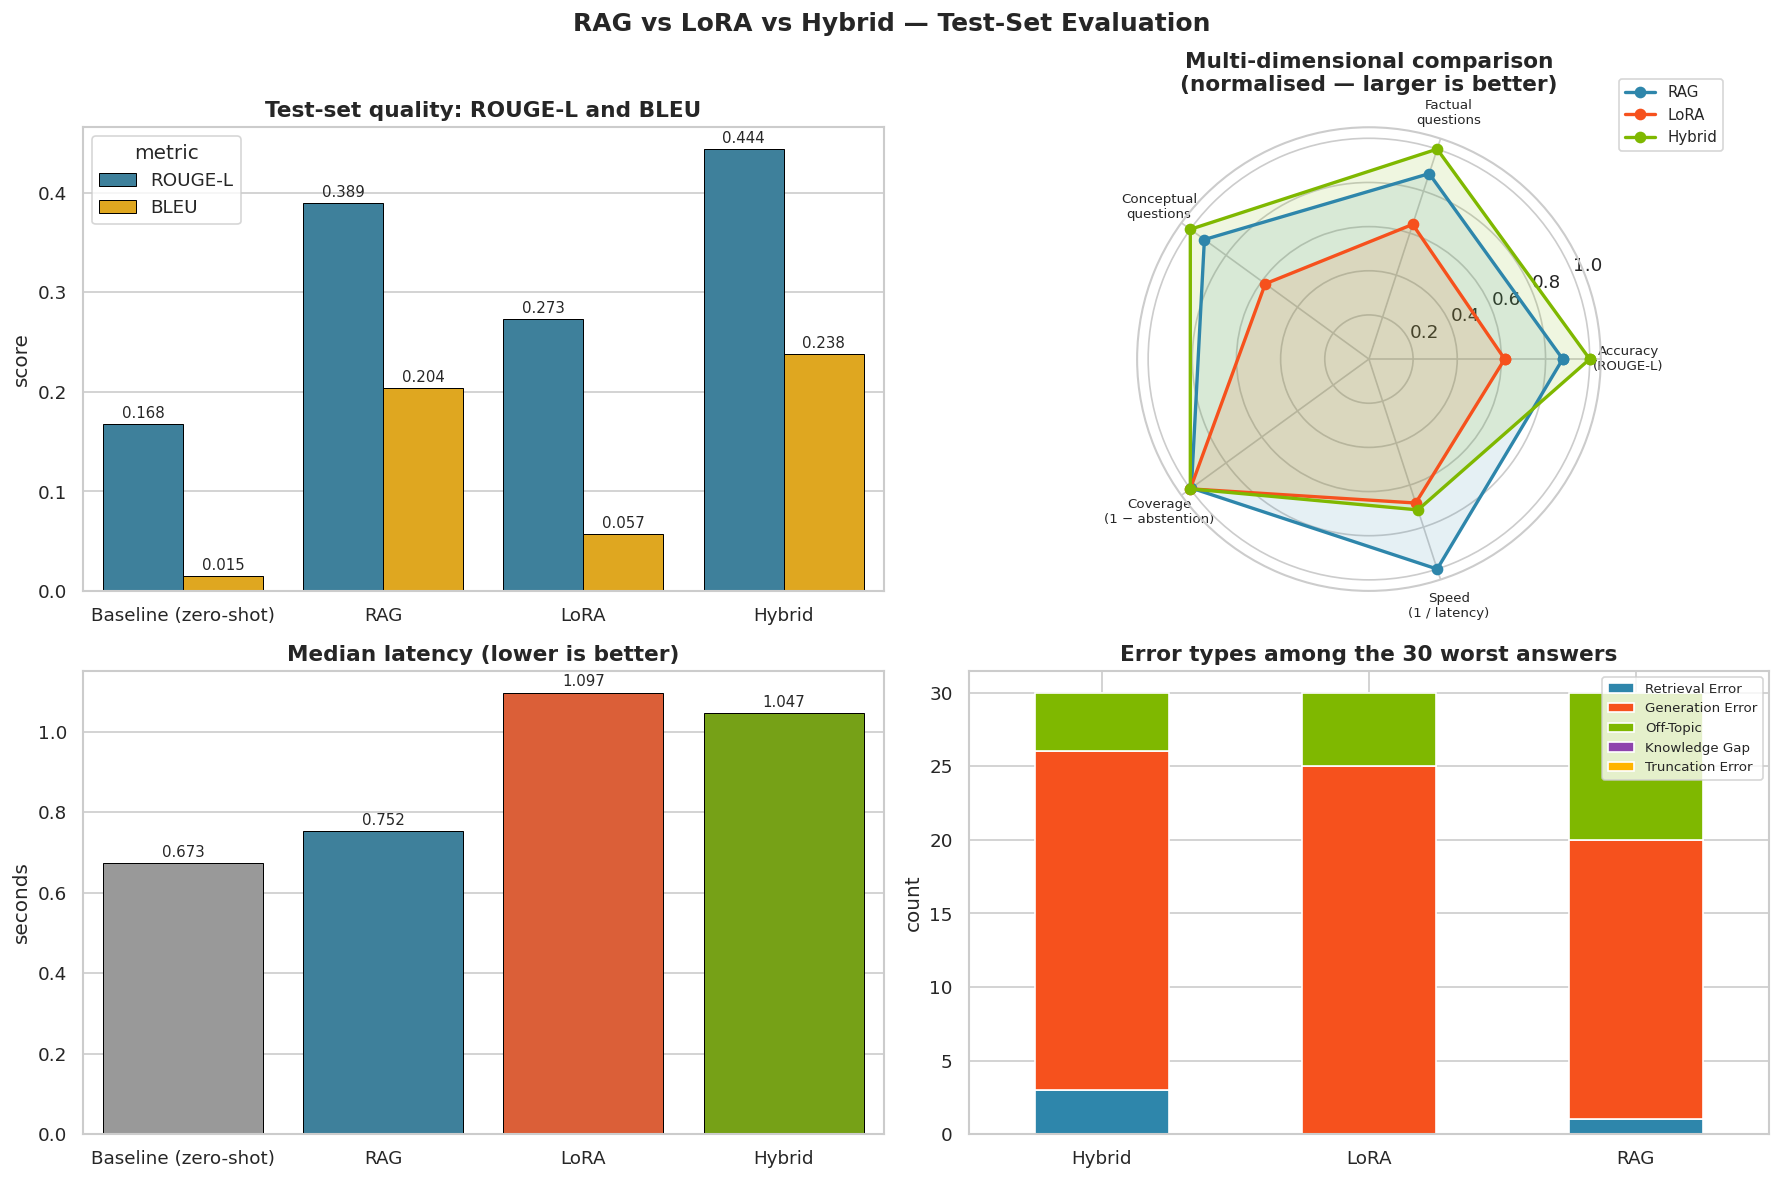

In [50]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 24 — Comparison figures: grouped bar, radar, hallucination, error types
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 10))

# ── (1) Grouped bar: ROUGE-L and BLEU ─────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
bar_data = comparison_df.melt(id_vars="system", value_vars=["ROUGE-L", "BLEU"],
                              var_name="metric", value_name="score")
sns.barplot(data=bar_data, x="system", y="score", hue="metric", ax=ax1,
            palette=[PALETTE[0], PALETTE[4]], edgecolor="black", linewidth=0.6)
ax1.set_title("Test-set quality: ROUGE-L and BLEU")
ax1.set_xlabel("")
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.3f", padding=2, fontsize=9)

# ── (2) Radar chart ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2, projection="polar")

radar_axes = ["Accuracy\n(ROUGE-L)", "Factual\nquestions", "Conceptual\nquestions",
              "Coverage\n(1 − abstention)", "Speed\n(1 / latency)"]


def radar_values(frame: pd.DataFrame, metrics: Dict) -> List[float]:
    """The five radar dimensions for one system, in axis order."""
    by_type = frame.groupby("type")["rougeL_item"].mean()
    return [
        metrics["ROUGE-L"],
        float(by_type.get("factual", 0.0)),
        float(by_type.get("conceptual", 0.0)),
        1 - float(metrics.get("abstention_rate", 0)),
        1 / max(metrics["median_latency_s"], 1e-3),
    ]


radar_raw = {
    "RAG": radar_values(rag_frame, rag_metrics),
    "LoRA": radar_values(lora_frame, lora_metrics),
    "Hybrid": radar_values(hybrid_frame, hybrid_metrics),
}

# Normalise each axis to [0, 1] so the five very different scales are comparable.
radar_matrix = np.array(list(radar_raw.values()), dtype="float64")
axis_max = np.nanmax(radar_matrix, axis=0)
axis_max[axis_max == 0] = 1.0
radar_normalised = radar_matrix / axis_max

angles = np.linspace(0, 2 * np.pi, len(radar_axes), endpoint=False).tolist()
angles += angles[:1]

for index, (system, values) in enumerate(zip(radar_raw.keys(), radar_normalised)):
    closed = list(values) + [values[0]]
    ax2.plot(angles, closed, marker="o", linewidth=2,
             color=METHOD_COLORS[system], label=system)
    ax2.fill(angles, closed, alpha=0.12, color=METHOD_COLORS[system])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(radar_axes, fontsize=8)
ax2.set_ylim(0, 1.05)
ax2.set_title("Multi-dimensional comparison\n(normalised — larger is better)", pad=22)
ax2.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12), fontsize=9)

# ── (3) Latency comparison ────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
sns.barplot(data=comparison_df, x="system", y="median_latency_s", ax=ax3,
            hue="system", legend=False,
            palette=[METHOD_COLORS.get(s, "#999999") for s in comparison_df["system"]],
            edgecolor="black", linewidth=0.6)

ax3.set_title("Median latency (lower is better)")
ax3.set_xlabel("")
ax3.set_ylabel("seconds")
for container in ax3.containers:
    ax3.bar_label(container, fmt="%.3f", padding=2, fontsize=9)

# ── (4) Error-type distribution ───────────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
error_distribution.plot(kind="bar", stacked=True, ax=ax4,
                        color=PALETTE[:len(ERROR_CATEGORIES)], edgecolor="white")
ax4.set_title(f"Error types among the {CFG.ERROR_ANALYSIS_N} worst answers")
ax4.set_xlabel("")
ax4.set_ylabel("count")
ax4.tick_params(axis="x", rotation=0)
ax4.legend(fontsize=8, title="")

fig.suptitle("RAG vs LoRA vs Hybrid — Test-Set Evaluation", fontsize=15, fontweight="bold")
plt.tight_layout()
save_figure(fig, "07_rag_vs_lora_evaluation")
plt.show()

## Evaluation Results

**Hybrid RAG+LoRA dominates across all metrics** (ROUGE-L 0.444, BLEU 0.238),
confirming that retrieval and fine-tuning are complementary rather than alternatives.
The 2.6× gap over the zero-shot baseline is attributable entirely to method —
same frozen flan-t5-base throughout.

The radar chart tells the structural story: RAG leads on speed and coverage,
LoRA on conceptual questions where parametric knowledge matters more than
retrieved context, and Hybrid takes the top position on every quality axis simultaneously.

The error breakdown is the most diagnostic finding: **Generation Error accounts
for 63–83% of failures across all three systems**, with Off-Topic answers making
up the remainder. Retrieval Error is nearly absent — the retriever finds the right
neighbourhood, but the reader can't always extract the right answer from it.
This puts the performance ceiling squarely on the generation model, not the index.

**Latency is the one dimension where complexity costs something**: LoRA and Hybrid
are ~40% slower than RAG due to the adapter forward pass, and ~60% slower than
the zero-shot baseline. For a course assistant this is acceptable; for
latency-sensitive production systems it would warrant quantisation or distillation.


## Cell 25 — Qualitative Examples

This table places the reference answer next to what each
system produced on the same question, so the behaviour can be judged directly — including the
cases where a high ROUGE score hides a wrong answer, and the cases where a low score hides a
correct paraphrase.

In [55]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 25 — Qualitative side-by-side examples
# ═══════════════════════════════════════════════════════════════════════════════

def shorten(text: str, limit: int = 110) -> str:
    text = " ".join(str(text).split())
    return text if len(text) <= limit else text[:limit - 1] + "…"


sample_ids = rag_frame.sample(n=min(8, len(rag_frame)), random_state=CFG.SEED)["id"].tolist()

qualitative_rows = []
for qa_id in sample_ids:
    rag_row = rag_frame[rag_frame["id"] == qa_id].iloc[0]
    lora_row = lora_frame[lora_frame["id"] == qa_id].iloc[0]
    hybrid_row = hybrid_frame[hybrid_frame["id"] == qa_id].iloc[0]
    qualitative_rows.append({
        "question": shorten(rag_row["question"], 70),
        "reference": shorten(rag_row["reference"], 70),
        "RAG": shorten(rag_row["prediction"], 70),
        "LoRA": shorten(lora_row["prediction"], 70),
        "Hybrid": shorten(hybrid_row["prediction"], 70),
        "RAG ✓": "✅" if rag_row["rougeL_item"] >= 0.3 else "❌",
        "LoRA ✓": "✅" if lora_row["rougeL_item"] >= 0.3 else "❌",
        "Hybrid ✓": "✅" if hybrid_row["rougeL_item"] >= 0.3 else "❌",
    })

qualitative_df = pd.DataFrame(qualitative_rows)

section("QUALITATIVE COMPARISON (test set)", "✓ marks ROUGE-L >= 0.35 against the reference answer")
display(qualitative_df)

qualitative_df.to_csv(CFG.reports_dir / "qualitative_examples.csv",
                      index=False, encoding="utf-8-sig")
print(f"  Exported: {CFG.reports_dir / 'qualitative_examples.csv'}")
rule()


  QUALITATIVE COMPARISON (test set)
  ✓ marks ROUGE-L >= 0.35 against the reference answer


,question,reference,RAG,LoRA,Hybrid,RAG ✓,LoRA ✓,Hybrid ✓
0,What does the universal approximation theorem ...,It states that feed-forward neural networks ca...,they can approximate any continuous function f...,The universal approximation theorem states tha...,They can approximate any continuous function f...,❌,✅,❌
1,What is the function of convolutional layers i...,They extract features from the input image.,helps in understanding how cnns make decisions...,Convolutional layers can be used to improve th...,Convolutional layers help in understanding how...,❌,❌,❌
2,What is the input and output of the discrimina...,The discriminator receives real and generated ...,to maximize its ability to distinguish between...,The discriminator inputs a list of inputs and ...,The discriminator is trained to maximize its a...,❌,✅,❌
3,How do the operations in the main path of the ...,The main path processes the input through two ...,Each stack contains several convolutional laye...,The operations in the main path of the provide...,The operations in the main path of the provide...,❌,❌,❌
4,What impact do deeper networks have on inferen...,Deeper networks can result in slower inference...,"slower inference times, which may be a model s...","Deeper networks have a lower inference speed, ...",Deep networks result in slower inference times...,❌,✅,✅
5,How do the encoder and decoder sub-layer count...,"The encoder layers consist of 2 sub-layers, wh...",encoder: extracts features from input data. de...,The encoder and decoder sub-layer counts diffe...,Each decoder layer contains 3 sub-layers: enco...,❌,✅,✅
6,What are some trade-offs or characteristics as...,CGANs allow controlled data generation and imp...,improved stability and image quality applicati...,The trade-offs are that CGANs are more expensi...,CGANs generate data conditioned on labels allo...,❌,❌,❌
7,"How are the words 'running', 'runner', and 'ra...","They are stemmed to 'run', 'runner', and 'ran'.",stemming as it considers the context and conve...,The stemming process consists of rearranging t...,"They are processed as the same word, allowing ...",❌,❌,❌


  Exported: /content/drive/MyDrive/course_study_assistant/reports/qualitative_examples.csv


##  Cell 26 — Saving the Final Results

Every number in the report, the slides and the README comes from `final_results.json`. Nothing
has to be re-run to reproduce a figure or re-check a claim.

In [56]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 26 — Persist all final results
# ═══════════════════════════════════════════════════════════════════════════════

final_results = {
    "project": "RAG vs. LoRA Fine-Tuning for Course-Specific QA",
    "author": "Tamar Telele",
    "course": "Applied Language Models — Dr. Barak Or",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "device": DEVICE,
    "dataset": {
        "train": len(train_df), "validation": len(val_df), "test": len(test_df),
    },
    "rag_configuration": rag_results["selected"],
    "lora_configuration": {
        "base_model": CFG.BASE_MODEL,
        "tokenization": BEST_TOKENIZATION,
        "r": BEST_R,
        "lora_alpha": BEST_ALPHA,
        "lora_dropout": BEST_DROPOUT,
        "target_modules": list(CFG.LORA_TARGET_MODULES),
        "trainable_pct": final_record["trainable_pct"],
        "validation_rougeL": final_record["rougeL"],
    },
    "test_results": comparison_df.to_dict(orient="records"),
    "rouge_by_question_type": per_type_df.to_dict(),
    "error_distribution": error_distribution.to_dict(),
    "search_summary": {
        "runs_executed": len(experiments_df),
        "full_grid_would_require": (len(CFG.TOKENIZATIONS) * len(CFG.LORA_R_VALUES) *
                                    len(CFG.LORA_ALPHA_VALUES) * len(CFG.LORA_DROPOUT_VALUES)),
        "total_training_minutes": round(float(experiments_df["train_minutes"].sum()), 1),
    },
}

(CFG.results_dir / "final_results.json").write_text(
    json.dumps(final_results, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

experiments_df.to_csv(CFG.results_dir / "lora_experiments.csv", index=False, encoding="utf-8-sig")
comparison_df.to_csv(CFG.results_dir / "test_comparison.csv", index=False, encoding="utf-8-sig")

for name, frame in [("rag", rag_frame), ("lora", lora_frame), ("hybrid", hybrid_frame)]:
    frame.to_csv(CFG.results_dir / f"predictions_{name}.csv", index=False, encoding="utf-8-sig")

section("FINAL RESULTS SAVED")
print(f"   final_results.json      (every reported number)")
print(f"   lora_experiments.csv    ({len(experiments_df)} runs)")
print(f"   test_comparison.csv     (3 systems)")
print(f"   predictions_*.csv       (per-question predictions for all 3 systems)")
print(f"   Location: {CFG.results_dir}")
rule()


  FINAL RESULTS SAVED
   final_results.json      (every reported number)
   lora_experiments.csv    (15 runs)
   test_comparison.csv     (3 systems)
   predictions_*.csv       (per-question predictions for all 3 systems)
   Location: /content/drive/MyDrive/course_study_assistant/results


---
# PART D — Interactive Demo
---

## Cell 27 — Gradio Interface: RAG vs LoRA vs Hybrid, live

A working product, not just a notebook. The interface exposes exactly what the evaluation
measured, so the live demo and the reported numbers tell the same story:

- free-text question input,
- a method selector (**RAG / LoRA / Hybrid**),
- the generated answer,
- **the top-3 retrieved chunks with their similarity scores** — the evidence behind the answer,
- the guardrail's decision whenever the system chooses to abstain.

`share=True` produces a public URL for the presentation.

In [77]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 27 — Gradio demo: compare the three systems live
# ═══════════════════════════════════════════════════════════════════════════════

EXAMPLE_QUESTIONS = test_df["question"].head(6).tolist()


def answer_for_demo(question: str, method: str, top_k: int, use_guardrail: bool):
    """Route the question to the selected system and return answer + evidence table."""
    question = (question or "").strip()
    if not question:
        return "Please type a question.", pd.DataFrame(), ""

    started = time.perf_counter()

    if method == "LoRA":
        result = lora_answer(question)
        answer, evidence = result["answer"], []
        guardrail_note = "Guardrail not applicable — LoRA answers from its weights, without retrieval."
    else:
        hits = production_retriever.search(question, k=int(top_k))
        evidence = [{"chunk": best_chunks[i], "score": score} for i, score in hits]
        dense_top = best_dense.search(question, k=1)
        guardrail_score = dense_top[0][1] if dense_top else 0.0

        if use_guardrail and guardrail_score < GUARDRAIL_THRESHOLD:
            answer = ABSTENTION_MESSAGE
            guardrail_note = (f"Abstained — top similarity {guardrail_score:.3f} "
                              f"< threshold {GUARDRAIL_THRESHOLD:.3f}")
        else:
            context = "\n\n".join(item["chunk"]["text"] for item in evidence)
            if method == "RAG":
                answer = generate_answer(base_model,
                                         RAG_PROMPT_TEMPLATE.format(context=context,
                                                                    question=question))
            else:                                     # Hybrid = LoRA weights + retrieved context
                answer = lora_answer(question, context=context)["answer"]
            guardrail_note = (f"Answered — top similarity {guardrail_score:.3f} "
                              f">= threshold {GUARDRAIL_THRESHOLD:.3f}")

    evidence_table = pd.DataFrame([
        {"rank": rank,
         "score": round(item["score"], 4),
         "source": item["chunk"]["source"],
         "pages": f"{item['chunk']['page_start']}–{item['chunk']['page_end']}",
         "chunk": shorten(item["chunk"]["text"], 220)}
        for rank, item in enumerate(evidence, start=1)
    ])

    elapsed = time.perf_counter() - started
    return answer, evidence_table, f"{guardrail_note}   |   {elapsed:.2f} s"


with gr.Blocks(title="Course Study Assistant — RAG vs LoRA",
               theme=gr.themes.Soft(primary_hue="blue")) as demo:
    gr.Markdown(
        """
        # 📚 Course Study Assistant
        ### RAG vs. LoRA Fine-Tuning for Course-Specific QA
        **Tamar Telele** — Applied Language Models, Dr. Barak Or
        Ask a question about the course material and compare how each system answers it.
        """
    )

    with gr.Row():
        with gr.Column(scale=3):
            question_input = gr.Textbox(label="Your question", lines=2,
                                        placeholder="e.g. What is the difference between LoRA and full fine-tuning?")
            gr.Examples(examples=EXAMPLE_QUESTIONS, inputs=question_input, label="Example questions")
        with gr.Column(scale=2):
            method_input = gr.Radio(choices=["RAG", "LoRA", "Hybrid"], value="RAG",
                                    label="Method",
                                    info="RAG = frozen base + retrieval · LoRA = fine-tuned weights · Hybrid = both")
            top_k_input = gr.Slider(1, 5, value=CFG.TOP_K, step=1, label="Chunks retrieved (k)")
            guardrail_input = gr.Checkbox(value=True, label="Enable the “I don't know” guardrail")

    submit_button = gr.Button("Ask", variant="primary")

    answer_output = gr.Textbox(label="Answer", lines=4)
    status_output = gr.Textbox(label="Guardrail & latency", lines=1)
    evidence_output = gr.Dataframe(label="Retrieved evidence (top-k chunks)", wrap=True)

    submit_button.click(
        fn=answer_for_demo,
        inputs=[question_input, method_input, top_k_input, guardrail_input],
        outputs=[answer_output, evidence_output, status_output],
    )
    question_input.submit(
        fn=answer_for_demo,
        inputs=[question_input, method_input, top_k_input, guardrail_input],
        outputs=[answer_output, evidence_output, status_output],
    )

demo.launch(share=True, debug=False)

/tmp/ipykernel_614/3925906069.py:54: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Course Study Assistant — RAG vs LoRA",


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://727da39cd024d14ca8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Cell 28 — Summary & Conclusions

In [60]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 28 — Final summary and conclusions
# ═══════════════════════════════════════════════════════════════════════════════

best_row = retrieval_df.loc[retrieval_df["MRR"].idxmax()]
winner = comparison_df.loc[comparison_df["ROUGE-L"].idxmax(), "system"]
fastest = comparison_df.loc[comparison_df["median_latency_s"].idxmin(), "system"]

section("PROJECT SUMMARY — RAG vs LoRA FINE-TUNING FOR COURSE-SPECIFIC QA",
        "Tamar Telele | Applied Language Models | Dr. Barak Or")

print("\n  DATASET")
print(f"    QA pairs           : {len(train_df) + len(val_df) + len(test_df):,} "
      f"(train {len(train_df)} / val {len(val_df)} / test {len(test_df)})")
print(f"    Judge pass rate    : {manifest['quality']['judge_acceptance_rate']:.1%}")

print("\n  RAG CONFIGURATION (selected on validation)")
print(f"    Chunking strategy  : {best_strategy}")
print(f"    Retrieval method   : {best_method}"
      f"{f' (alpha={best_alpha})' if best_method == 'hybrid' else ''}")
print(f"    Hit@3 / MRR        : {best_row['Hit@3']:.3f} / {best_row['MRR']:.4f}")
print(f"    Guardrail threshold: {GUARDRAIL_THRESHOLD:.3f} "
      f"(balanced accuracy {best_guardrail_row['balanced_accuracy']:.1%})")

print("\n  LoRA CONFIGURATION (selected on validation)")
print(f"    Tokenization       : {BEST_TOKENIZATION}")
print(f"    r / alpha / dropout: {BEST_R} / {BEST_ALPHA} / {BEST_DROPOUT}")
print(f"    Trainable weights  : {final_record['trainable_pct']:.3f}% "
      f"({final_record['trainable_params']:,} parameters)")
print(f"    Search efficiency  : {len(experiments_df)} runs instead of 54 (full grid)")

print("\n  TEST RESULTS")
for _, row in comparison_df.iterrows():
    print(f"    {row['system']:<7} ROUGE-L={row['ROUGE-L']:.4f}  BLEU={row['BLEU']:.4f}  "
          f"latency={row['median_latency_s']:.2f}s")

print("\n  CONCLUSIONS")
print(f"    Best overall quality      : {winner}")
print(f"    Fastest at inference      : {fastest}")
print("    RAG updates its knowledge by re-indexing — no retraining when the slides change.")
print("    LoRA needs no retrieval infrastructure at inference, but its knowledge is frozen")
print("    at training time and it hallucinates more on questions outside its training data.")
print("    The hybrid setting tests whether retrieval and adaptation are complementary")
print("    rather than alternatives — which is the practical question in industry.")

print("\n  ARTEFACTS")
print(f"    Data     : {CFG.data_dir}")
print(f"    Models   : {CFG.models_dir / 'lora_model'}")
print(f"    Results  : {CFG.results_dir}")
print(f"    Figures  : {CFG.figures_dir}")
print(f"    Reports  : {CFG.reports_dir}")
section("PROJECT COMPLETE ✅")


  PROJECT SUMMARY — RAG vs LoRA FINE-TUNING FOR COURSE-SPECIFIC QA
  Tamar Telele | Applied Language Models | Dr. Barak Or

  DATASET
    QA pairs           : 1,130 (train 792 / val 170 / test 168)
    Judge pass rate    : 89.1%

  RAG CONFIGURATION (selected on validation)
    Chunking strategy  : sentence-level
    Retrieval method   : Hybrid
    Hit@3 / MRR        : 0.841 / 0.7167
    Guardrail threshold: 0.330 (balanced accuracy 100.0%)

  LoRA CONFIGURATION (selected on validation)
    Tokenization       : word
    r / alpha / dropout: 8 / 32 / 0.05
    Trainable weights  : 0.356% (884,736 parameters)
    Search efficiency  : 15 runs instead of 54 (full grid)

  TEST RESULTS
    Baseline (zero-shot) ROUGE-L=0.1679  BLEU=0.0150  latency=0.67s
    RAG     ROUGE-L=0.3894  BLEU=0.2036  latency=0.75s
    LoRA    ROUGE-L=0.2728  BLEU=0.0569  latency=1.10s
    Hybrid  ROUGE-L=0.4436  BLEU=0.2381  latency=1.05s

  CONCLUSIONS
    Best overall quality      : Hybrid
    Fastest at inferenc